STEP 1: LOAD HAM10000 DATASET AND CONNECT IMAGE PATHS


In [ ]:
# ============================================================
# STEP 1: LOAD HAM10000 DATASET AND CONNECT IMAGE PATHS
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

# Main extracted dataset path
base_path = "/content/drive/MyDrive/DeepLearningProject/HAM10000/extracted"

# Metadata file and image folders
metadata_path = os.path.join(base_path, "HAM10000_metadata.csv")
image_dir_1 = os.path.join(base_path, "HAM10000_images_part_1")
image_dir_2 = os.path.join(base_path, "HAM10000_images_part_2")

# Check files/folders
print("Metadata exists:", os.path.exists(metadata_path))
print("Image folder 1 exists:", os.path.exists(image_dir_1))
print("Image folder 2 exists:", os.path.exists(image_dir_2))

# Load metadata
df = pd.read_csv(metadata_path)

print("\nOriginal metadata shape:", df.shape)
display(df.head())

# Connect image_id with actual image paths
image_paths = {}

for folder in [image_dir_1, image_dir_2]:
    for img_name in os.listdir(folder):
        if img_name.endswith(".jpg"):
            image_id = img_name.replace(".jpg", "")
            image_paths[image_id] = os.path.join(folder, img_name)

# Add image_path column
df["image_path"] = df["image_id"].map(image_paths)

# Keep only columns needed for CNN
df = df[["image_id", "image_path", "dx"]]

# Remove rows with missing image path if any
df = df.dropna(subset=["image_path"])

print("\nAfter connecting image paths:")
print("Total records:", len(df))
print("Missing image paths:", df["image_path"].isnull().sum())

display(df.head())

Metadata exists: True
Image folder 1 exists: True
Image folder 2 exists: True

Original metadata shape: (10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear



After connecting image paths:
Total records: 10015
Missing image paths: 0


,image_id,image_path,dx
0,ISIC_0027419,/content/drive/MyDrive/DeepLearningProject/HAM...,bkl
1,ISIC_0025030,/content/drive/MyDrive/DeepLearningProject/HAM...,bkl
2,ISIC_0026769,/content/drive/MyDrive/DeepLearningProject/HAM...,bkl
3,ISIC_0025661,/content/drive/MyDrive/DeepLearningProject/HAM...,bkl
4,ISIC_0031633,/content/drive/MyDrive/DeepLearningProject/HAM...,bkl


STEP 2: CHECK CLASS DISTRIBUTION AND SAVE CLEAN CSV

Total classes: 7

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


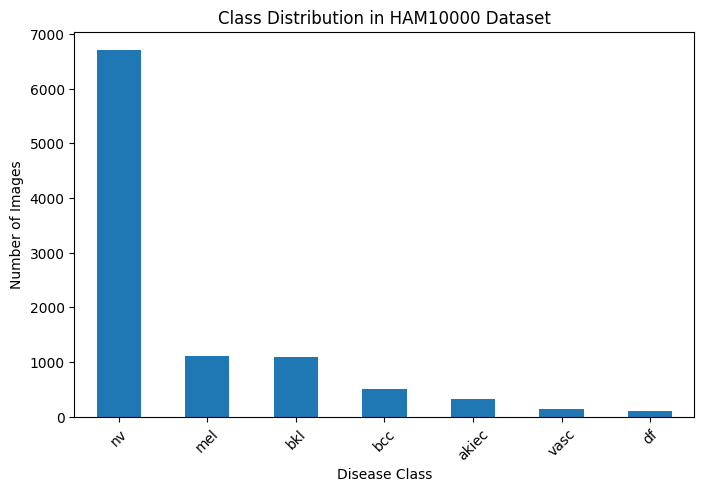


Clean CSV saved at:
/content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/HAM10000_cleaned_simple.csv


In [ ]:
# ============================================================
# STEP 2: CHECK CLASS DISTRIBUTION AND SAVE CLEAN CSV
# ============================================================

# Check number of classes
print("Total classes:", df["dx"].nunique())

# Class distribution
class_counts = df["dx"].value_counts()
print("\nClass distribution:")
print(class_counts)

# Plot class distribution
plt.figure(figsize=(8, 5))
class_counts.plot(kind="bar")
plt.title("Class Distribution in HAM10000 Dataset")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

# Save clean CSV
clean_csv_path = os.path.join(base_path, "HAM10000_cleaned_simple.csv")
df.to_csv(clean_csv_path, index=False)

print("\nClean CSV saved at:"),
print(clean_csv_path)

STEP 3: TRAIN / VALIDATION / TEST SPLIT

In [ ]:
# ============================================================
# STEP 3: TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# 70% train, 30% temporary
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["dx"],
    random_state=42
)

# temporary 30% → 20% validation and 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=1/3,
    stratify=temp_df["dx"],
    random_state=42
)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Testing samples:", len(test_df))

print("\nTrain class distribution:")
print(train_df["dx"].value_counts())

print("\nValidation class distribution:")
print(val_df["dx"].value_counts())

print("\nTest class distribution:")
print(test_df["dx"].value_counts())

# Save split CSV files
split_path = os.path.join(base_path, "splits")
os.makedirs(split_path, exist_ok=True)

train_df.to_csv(os.path.join(split_path, "train.csv"), index=False)
val_df.to_csv(os.path.join(split_path, "val.csv"), index=False)
test_df.to_csv(os.path.join(split_path, "test.csv"), index=False)

print("\nSplit files saved at:")
print(split_path)

Training samples: 7010
Validation samples: 2003
Testing samples: 1002

Train class distribution:
dx
nv       4693
mel       779
bkl       769
bcc       360
akiec     229
vasc       99
df         81
Name: count, dtype: int64

Validation class distribution:
dx
nv       1341
mel       222
bkl       220
bcc       103
akiec      65
vasc       29
df         23
Name: count, dtype: int64

Test class distribution:
dx
nv       671
mel      112
bkl      110
bcc       51
akiec     33
vasc      14
df        11
Name: count, dtype: int64

Split files saved at:
/content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/splits


STEP 4: IMAGE PREPROCESSING AND DATA GENERATORS

In [ ]:
# ============================================================
# STEP 4: IMAGE PREPROCESSING AND DATA GENERATORS
# ============================================================

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

# Validation/test generator: only normalization
val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="dx",
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="dx",
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="dx",
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("\nClass indices:")
print(train_generator.class_indices)

Found 7010 validated image filenames belonging to 7 classes.
Found 2003 validated image filenames belonging to 7 classes.
Found 1002 validated image filenames belonging to 7 classes.

Class indices:
{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


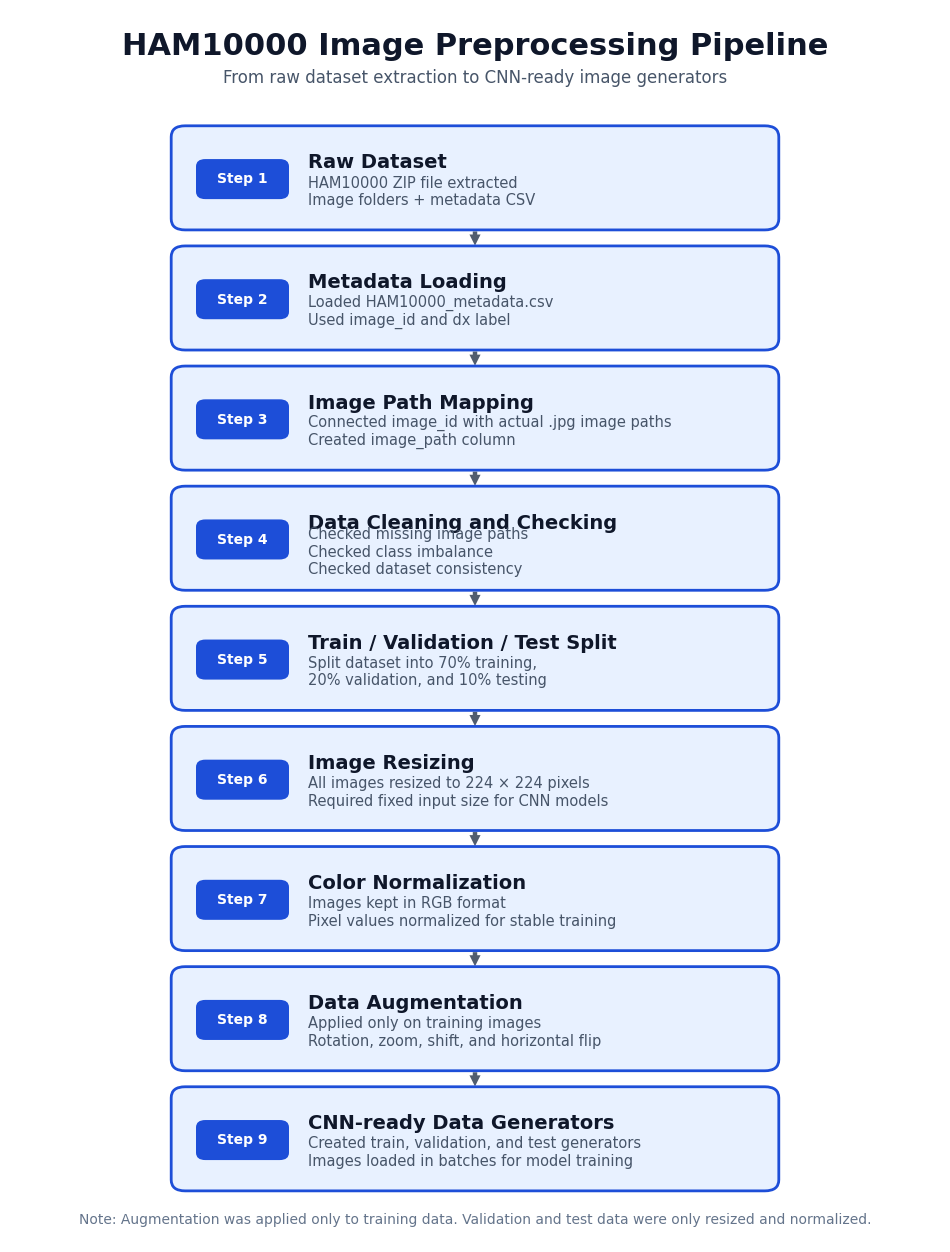

Clean preprocessing pipeline saved at:
/content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/preprocessing_pipeline_clean.png


In [ ]:
# ============================================================
# CLEAN PREPROCESSING PIPELINE VISUALIZATION
# HAM10000 Skin Lesion Classification
# Vertical professional pipeline diagram
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# ------------------------------------------------------------
# Pipeline steps
# ------------------------------------------------------------

steps = [
    ("Raw Dataset",
     "HAM10000 ZIP file extracted\nImage folders + metadata CSV"),

    ("Metadata Loading",
     "Loaded HAM10000_metadata.csv\nUsed image_id and dx label"),

    ("Image Path Mapping",
     "Connected image_id with actual .jpg image paths\nCreated image_path column"),

    ("Data Cleaning and Checking",
     "Checked missing image paths\nChecked class imbalance\nChecked dataset consistency"),

    ("Train / Validation / Test Split",
     "Split dataset into 70% training,\n20% validation, and 10% testing"),

    ("Image Resizing",
     "All images resized to 224 × 224 pixels\nRequired fixed input size for CNN models"),

    ("Color Normalization",
     "Images kept in RGB format\nPixel values normalized for stable training"),

    ("Data Augmentation",
     "Applied only on training images\nRotation, zoom, shift, and horizontal flip"),

    ("CNN-ready Data Generators",
     "Created train, validation, and test generators\nImages loaded in batches for model training")
]

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 16))
ax.set_xlim(0, 12)
ax.set_ylim(0, 20)
ax.axis("off")

# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------

box_x = 2.2
box_width = 7.6
box_height = 1.45
start_y = 18
gap = 1.95

box_face = "#e8f1ff"
box_edge = "#1d4ed8"
arrow_color = "#334155"
title_color = "#0f172a"
desc_color = "#475569"

# ------------------------------------------------------------
# Main title
# ------------------------------------------------------------

ax.text(
    6, 19.4,
    "HAM10000 Image Preprocessing Pipeline",
    ha="center",
    va="center",
    fontsize=22,
    fontweight="bold",
    color=title_color
)

ax.text(
    6, 18.9,
    "From raw dataset extraction to CNN-ready image generators",
    ha="center",
    va="center",
    fontsize=12,
    color=desc_color
)

# ------------------------------------------------------------
# Draw pipeline boxes
# ------------------------------------------------------------

for i, (title, description) in enumerate(steps):
    y = start_y - (i * gap)

    # Rounded rectangle box
    box = FancyBboxPatch(
        (box_x, y - box_height),
        box_width,
        box_height,
        boxstyle="round,pad=0.12,rounding_size=0.18",
        linewidth=2,
        edgecolor=box_edge,
        facecolor=box_face
    )
    ax.add_patch(box)

    # Step number badge
    badge = FancyBboxPatch(
        (box_x + 0.25, y - 1.02),
        1.1,
        0.55,
        boxstyle="round,pad=0.05,rounding_size=0.12",
        linewidth=0,
        facecolor="#1d4ed8"
    )
    ax.add_patch(badge)

    ax.text(
        box_x + 0.8,
        y - 0.75,
        f"Step {i+1}",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="white"
    )

    # Step title
    ax.text(
        box_x + 1.65,
        y - 0.48,
        title,
        ha="left",
        va="center",
        fontsize=14,
        fontweight="bold",
        color=title_color
    )

    # Description
    ax.text(
        box_x + 1.65,
        y - 0.95,
        description,
        ha="left",
        va="center",
        fontsize=10.5,
        color=desc_color
    )

    # Arrow between boxes
    if i < len(steps) - 1:
        arrow = FancyArrowPatch(
            (6, y - box_height - 0.10),
            (6, y - gap + 0.08),
            arrowstyle="simple",
            mutation_scale=16,
            linewidth=0,
            color=arrow_color,
            alpha=0.85
        )
        ax.add_patch(arrow)

# ------------------------------------------------------------
# Footer note
# ------------------------------------------------------------

ax.text(
    6, 0.35,
    "Note: Augmentation was applied only to training data. Validation and test data were only resized and normalized.",
    ha="center",
    va="center",
    fontsize=10,
    color="#64748b"
)

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

pipeline_path = "/content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/preprocessing_pipeline_clean.png"

plt.savefig(pipeline_path, dpi=300, bbox_inches="tight")
plt.show()

print("Clean preprocessing pipeline saved at:")
print(pipeline_path)

STEP 5: CHECK PREPROCESSED IMAGES


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 7)
Minimum pixel value: 3.5283327e-05
Maximum pixel value: 1.0


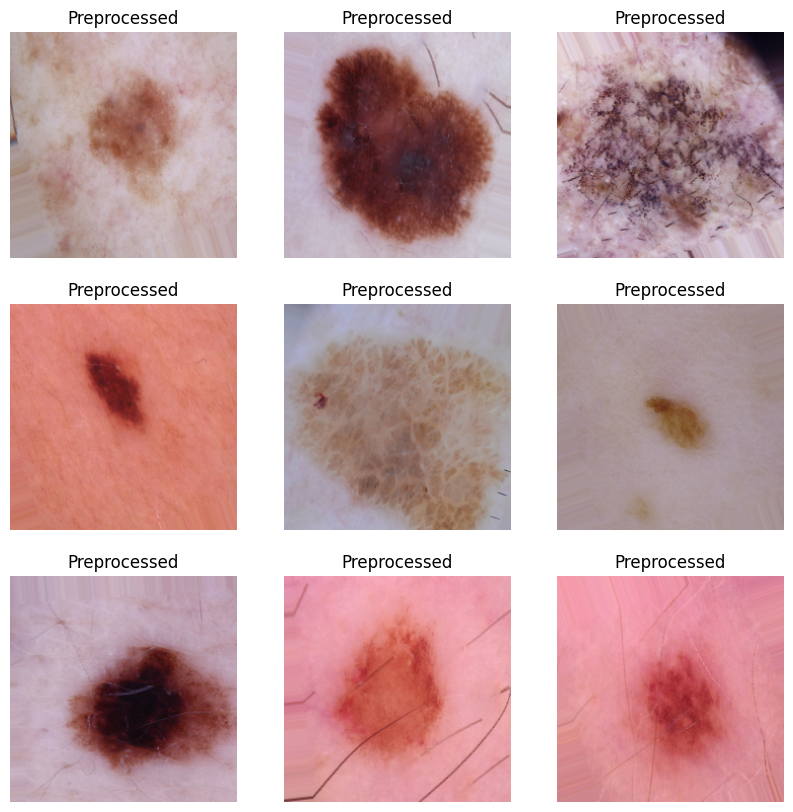

In [ ]:
# ============================================================
# STEP 5: CHECK PREPROCESSED IMAGES
# ============================================================

images, labels = next(train_generator)

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Minimum pixel value:", images.min())
print("Maximum pixel value:", images.max())

plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title("Preprocessed")
    plt.axis("off")

plt.show()

MODEL 1: SIMPLE CNN BASELINE MODEL

Model 1 results will be saved at:
/content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_1_baseline_results
Input shape: (224, 224, 3)
Number of classes: 7
Class labels: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Model_1_Simple_CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,863 (42.61 MB)

 Trainable params: 11,169,863 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Model summary saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_1_baseline_results/model_1_summary.txt
Epoch 1/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6422 - loss: 1.2976
Epoch 1: val_loss improved from None to 0.91952, saving model to /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_1_baseline_results/model_1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_1_baseline_results/model_1_best.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 2033s 9s/step - accuracy: 0.6633 - loss: 1.1002 - val_accuracy: 0.6695 - val_loss: 0.9195
Epoch 2/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 710ms/step - accuracy: 0.6632 - loss: 1.0048
Epoch 2: val_loss improved from 0.91952 to 0.87416, saving model to /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_1_baseline_results/model_1_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DeepLearningProject/HAM10000/extr

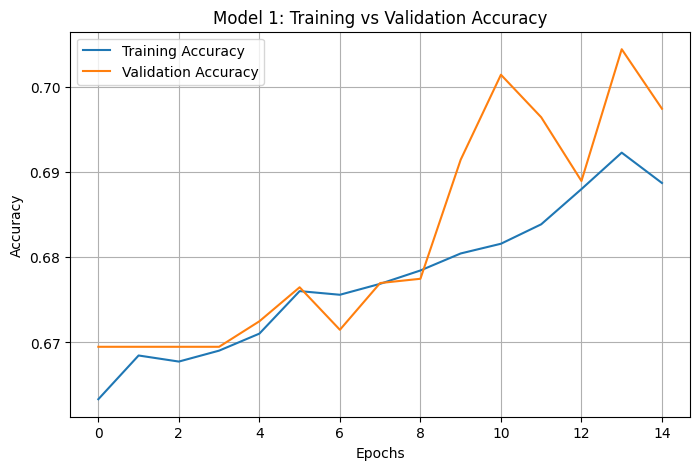

Accuracy curve saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_1_baseline_results/model_1_accuracy_curve.png


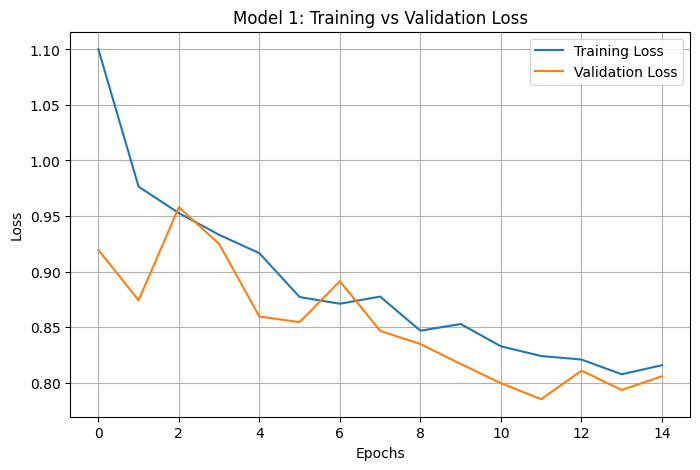

Loss curve saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_1_baseline_results/model_1_loss_curve.png
32/32 ━━━━━━━━━━━━━━━━━━━━ 207s 7s/step - accuracy: 0.6966 - loss: 0.8031
Model 1 Test Loss: 0.8030996918678284
Model 1 Test Accuracy: 0.6966068148612976
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 325ms/step
y_true, y_pred, and y_pred_probs saved successfully.
Accuracy: 0.6966067864271457
Macro Precision: 0.36367156939446094
Macro Recall: 0.23066383036075827
Macro F1-score: 0.24351083336045742
Weighted F1-score: 0.6054947331735859
Classification Report:


,precision,recall,f1-score,support
akiec,0.000000,0.000000,0.000000,33.000000
bcc,0.400000,0.039216,0.071429,51.000000
bkl,0.425000,0.309091,0.357895,110.000000
df,0.000000,0.000000,0.000000,11.000000
mel,0.000000,0.000000,0.000000,112.000000
nv,0.720701,0.980626,0.830808,671.000000
vasc,1.000000,0.285714,0.444444,14.000000
accuracy,0.696607,0.696607,0.696607,0.696607
macro avg,0.363672,0.230664,0.243511,1002.000000
weighted avg,0.563613,0.696607,0.605495,1002.000000


Classification report saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_1_baseline_results/model_1_classification_report.csv
Confusion matrix saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_1_baseline_results/model_1_confusion_matrix.csv


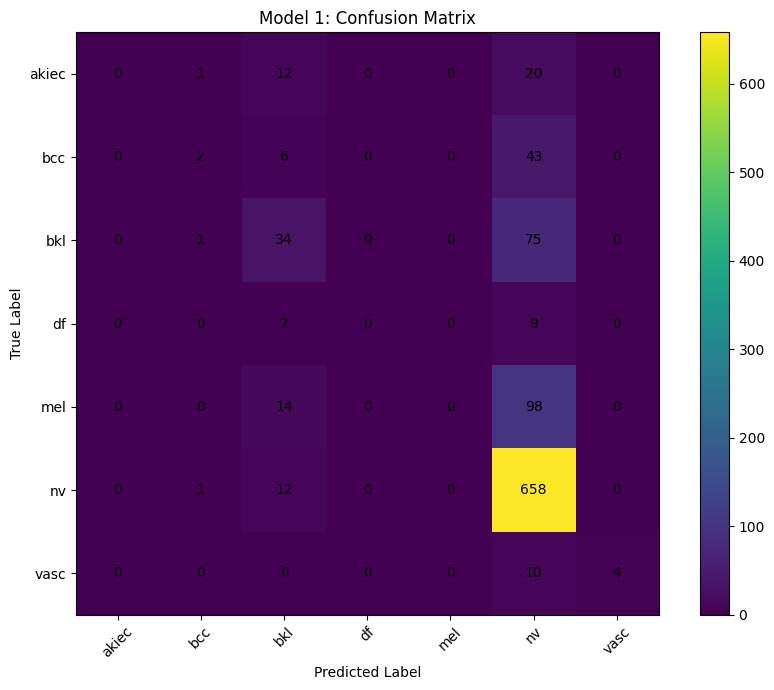

Confusion matrix plot saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_1_baseline_results/model_1_confusion_matrix.png
Metrics saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_1_baseline_results/model_1_metrics.json

MODEL 1 BASELINE COMPLETED SUCCESSFULLY
Test Accuracy: 0.6966068148612976
Macro F1-score: 0.24351083336045742
Weighted F1-score: 0.6054947331735859
All Model 1 results saved in:
/content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_1_baseline_results


In [ ]:
# ============================================================
# MODEL 1: SIMPLE CNN BASELINE MODEL
# Dataset: HAM10000
# Purpose:
# 1. Build a simple CNN model
# 2. Train the model
# 3. Evaluate on test data
# 4. Save model, history, predictions, and evaluation results
# ============================================================

# ------------------------------------------------------------
# 1. Import required libraries
# ------------------------------------------------------------

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# 2. Create folder to save Model 1 results
# ------------------------------------------------------------

model1_path = os.path.join(base_path, "model_1_baseline_results")
os.makedirs(model1_path, exist_ok=True)

print("Model 1 results will be saved at:")
print(model1_path)

# ------------------------------------------------------------
# 3. Define model settings
# ------------------------------------------------------------

INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, 3)

# Number of output classes
NUM_CLASSES = len(train_generator.class_indices)

# Class labels in correct order
class_labels = list(train_generator.class_indices.keys())

print("Input shape:", INPUT_SHAPE)
print("Number of classes:", NUM_CLASSES)
print("Class labels:", class_labels)

# ------------------------------------------------------------
# 4. Build Simple CNN Baseline Model
# ------------------------------------------------------------
# This is the first basic model.
# Conv2D layers extract image features.
# MaxPooling reduces image size and computation.
# ReLU activation helps the model learn non-linear patterns.
# Dropout reduces overfitting.
# Softmax is used because this is a multi-class classification problem.

model_1 = Sequential(name="Model_1_Simple_CNN_Baseline")

# First convolution block
model_1.add(Conv2D(32, (3, 3), activation="relu", input_shape=INPUT_SHAPE))
model_1.add(MaxPooling2D(pool_size=(2, 2)))

# Second convolution block
model_1.add(Conv2D(64, (3, 3), activation="relu"))
model_1.add(MaxPooling2D(pool_size=(2, 2)))

# Third convolution block
model_1.add(Conv2D(128, (3, 3), activation="relu"))
model_1.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten feature maps into one vector
model_1.add(Flatten())

# Dense classification layer
model_1.add(Dense(128, activation="relu"))

# Dropout to reduce overfitting
model_1.add(Dropout(0.5))

# Output layer
model_1.add(Dense(NUM_CLASSES, activation="softmax"))

# ------------------------------------------------------------
# 5. Compile the model
# ------------------------------------------------------------
# Adam optimizer is used for baseline training.
# categorical_crossentropy is used because labels are one-hot encoded.

model_1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Show model architecture
model_1.summary()

# Save model summary as text file
summary_path = os.path.join(model1_path, "model_1_summary.txt")

with open(summary_path, "w") as f:
    model_1.summary(print_fn=lambda x: f.write(x + "\n"))

print("Model summary saved at:", summary_path)

# ------------------------------------------------------------
# 6. Define callbacks
# ------------------------------------------------------------

# EarlyStopping stops training if validation loss does not improve.
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# ModelCheckpoint saves the best model based on validation loss.
best_model_path = os.path.join(model1_path, "model_1_best.keras")

checkpoint = ModelCheckpoint(
    best_model_path,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# CSVLogger saves epoch-by-epoch training values.
training_log_path = os.path.join(model1_path, "model_1_training_log.csv")

csv_logger = CSVLogger(
    training_log_path,
    append=False
)

# ------------------------------------------------------------
# 7. Train the baseline model
# ------------------------------------------------------------

EPOCHS = 15

history_model_1 = model_1.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint, csv_logger],
    verbose=1
)

# ------------------------------------------------------------
# 8. Save final trained model
# ------------------------------------------------------------

final_model_path = os.path.join(model1_path, "model_1_final.keras")
model_1.save(final_model_path)

print("Final Model 1 saved at:", final_model_path)
print("Best Model 1 saved at:", best_model_path)

# ------------------------------------------------------------
# 9. Save training history
# ------------------------------------------------------------

history_df = pd.DataFrame(history_model_1.history)

history_csv_path = os.path.join(model1_path, "model_1_history.csv")
history_df.to_csv(history_csv_path, index=False)

print("Training history saved at:", history_csv_path)

# ------------------------------------------------------------
# 10. Plot and save accuracy curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(history_model_1.history["accuracy"], label="Training Accuracy")
plt.plot(history_model_1.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model 1: Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

accuracy_plot_path = os.path.join(model1_path, "model_1_accuracy_curve.png")
plt.savefig(accuracy_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Accuracy curve saved at:", accuracy_plot_path)

# ------------------------------------------------------------
# 11. Plot and save loss curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(history_model_1.history["loss"], label="Training Loss")
plt.plot(history_model_1.history["val_loss"], label="Validation Loss")
plt.title("Model 1: Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

loss_plot_path = os.path.join(model1_path, "model_1_loss_curve.png")
plt.savefig(loss_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Loss curve saved at:", loss_plot_path)

# ------------------------------------------------------------
# 12. Load best model for final evaluation
# ------------------------------------------------------------

best_model_1 = load_model(best_model_path)

# ------------------------------------------------------------
# 13. Evaluate on test data
# ------------------------------------------------------------

test_loss_1, test_accuracy_1 = best_model_1.evaluate(test_generator)

print("Model 1 Test Loss:", test_loss_1)
print("Model 1 Test Accuracy:", test_accuracy_1)

# ------------------------------------------------------------
# 14. Predict test data
# ------------------------------------------------------------
# test_generator shuffle must be False so predictions match true labels.

test_generator.reset()

y_pred_probs_1 = best_model_1.predict(test_generator)

# Convert probability predictions into class indices
y_pred_1 = np.argmax(y_pred_probs_1, axis=1)

# True labels
y_true_1 = test_generator.classes

# ------------------------------------------------------------
# 15. Save y_true, y_pred, and prediction probabilities
# ------------------------------------------------------------

np.save(os.path.join(model1_path, "model_1_y_true.npy"), y_true_1)
np.save(os.path.join(model1_path, "model_1_y_pred.npy"), y_pred_1)
np.save(os.path.join(model1_path, "model_1_y_pred_probs.npy"), y_pred_probs_1)

print("y_true, y_pred, and y_pred_probs saved successfully.")

# ------------------------------------------------------------
# 16. Calculate evaluation metrics
# ------------------------------------------------------------

accuracy_1 = accuracy_score(y_true_1, y_pred_1)
precision_macro_1 = precision_score(y_true_1, y_pred_1, average="macro", zero_division=0)
recall_macro_1 = recall_score(y_true_1, y_pred_1, average="macro", zero_division=0)
f1_macro_1 = f1_score(y_true_1, y_pred_1, average="macro", zero_division=0)

precision_weighted_1 = precision_score(y_true_1, y_pred_1, average="weighted", zero_division=0)
recall_weighted_1 = recall_score(y_true_1, y_pred_1, average="weighted", zero_division=0)
f1_weighted_1 = f1_score(y_true_1, y_pred_1, average="weighted", zero_division=0)

print("Accuracy:", accuracy_1)
print("Macro Precision:", precision_macro_1)
print("Macro Recall:", recall_macro_1)
print("Macro F1-score:", f1_macro_1)
print("Weighted F1-score:", f1_weighted_1)

# ------------------------------------------------------------
# 17. Classification report
# ------------------------------------------------------------

report_dict_1 = classification_report(
    y_true_1,
    y_pred_1,
    target_names=class_labels,
    output_dict=True,
    zero_division=0
)

report_df_1 = pd.DataFrame(report_dict_1).transpose()

report_path = os.path.join(model1_path, "model_1_classification_report.csv")
report_df_1.to_csv(report_path)

print("Classification Report:")
display(report_df_1)

print("Classification report saved at:", report_path)

# ------------------------------------------------------------
# 18. Confusion matrix
# ------------------------------------------------------------

cm_1 = confusion_matrix(y_true_1, y_pred_1)

cm_df_1 = pd.DataFrame(
    cm_1,
    index=class_labels,
    columns=class_labels
)

cm_csv_path = os.path.join(model1_path, "model_1_confusion_matrix.csv")
cm_df_1.to_csv(cm_csv_path)

print("Confusion matrix saved at:", cm_csv_path)

# Plot confusion matrix
plt.figure(figsize=(9, 7))
plt.imshow(cm_1, interpolation="nearest")
plt.title("Model 1: Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_labels))
plt.xticks(tick_marks, class_labels, rotation=45)
plt.yticks(tick_marks, class_labels)

for i in range(cm_1.shape[0]):
    for j in range(cm_1.shape[1]):
        plt.text(j, i, cm_1[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

cm_plot_path = os.path.join(model1_path, "model_1_confusion_matrix.png")
plt.savefig(cm_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix plot saved at:", cm_plot_path)

# ------------------------------------------------------------
# 19. Save final metrics as JSON
# ------------------------------------------------------------

metrics_1 = {
    "model_name": "Model_1_Simple_CNN_Baseline",
    "test_loss": float(test_loss_1),
    "test_accuracy": float(test_accuracy_1),
    "accuracy_score": float(accuracy_1),
    "precision_macro": float(precision_macro_1),
    "recall_macro": float(recall_macro_1),
    "f1_macro": float(f1_macro_1),
    "precision_weighted": float(precision_weighted_1),
    "recall_weighted": float(recall_weighted_1),
    "f1_weighted": float(f1_weighted_1),
    "class_labels": class_labels,
    "best_model_path": best_model_path,
    "final_model_path": final_model_path
}

metrics_path = os.path.join(model1_path, "model_1_metrics.json")

with open(metrics_path, "w") as f:
    json.dump(metrics_1, f, indent=4)

print("Metrics saved at:", metrics_path)

# ------------------------------------------------------------
# 20. Final summary
# ------------------------------------------------------------

print("\nMODEL 1 BASELINE COMPLETED SUCCESSFULLY")
print("Test Accuracy:", test_accuracy_1)
print("Macro F1-score:", f1_macro_1)
print("Weighted F1-score:", f1_weighted_1)
print("All Model 1 results saved in:")
print(model1_path)

MODEL 2: IMPROVED CNN MODEL

Model 2 results will be saved at:
/content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_2_improved_cnn_results
Input shape: (224, 224, 3)
Number of classes: 7
Class labels: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

Class weights:
{0: np.float64(4.37305053025577), 1: np.float64(2.7817460317460316), 2: np.float64(1.3022478172023035), 3: np.float64(12.36331569664903), 4: np.float64(1.285530900421786), 5: np.float64(0.21338772031292808), 6: np.float64(10.115440115440116)}
Class weights saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_2_improved_cnn_results/model_2_class_weights.json


Model: "Model_2_Improved_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 489,927 (1.87 MB)

 Trainable params: 488,967 (1.87 MB)

 Non-trainable params: 960 (3.75 KB)

Model summary saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_2_improved_cnn_results/model_2_summary.txt
Epoch 1/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 708ms/step - accuracy: 0.3934 - loss: 1.9619
Epoch 1: val_loss improved from None to 2.64374, saving model to /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_2_improved_cnn_results/model_2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_2_improved_cnn_results/model_2_best.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 188s 819ms/step - accuracy: 0.3950 - loss: 1.8864 - val_accuracy: 0.1108 - val_loss: 2.6437 - learning_rate: 5.0000e-04
Epoch 2/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 692ms/step - accuracy: 0.4296 - loss: 1.7403
Epoch 2: val_loss improved from 2.64374 to 1.72881, saving model to /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_2_improved_cnn_results/model_2_best.keras

Epoch 2: finished saving model to /conten

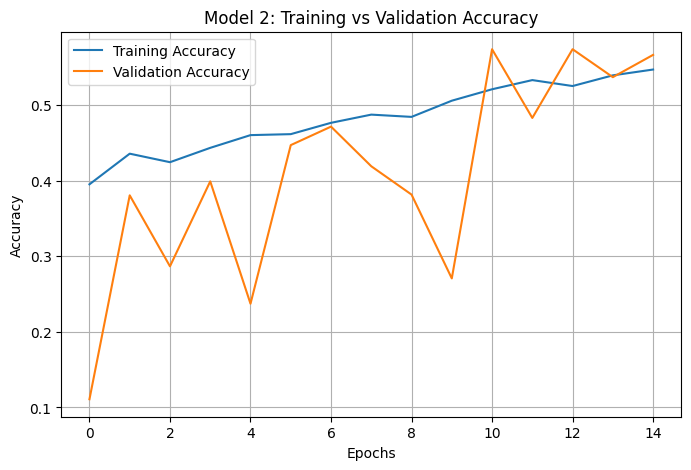

Accuracy curve saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_2_improved_cnn_results/model_2_accuracy_curve.png


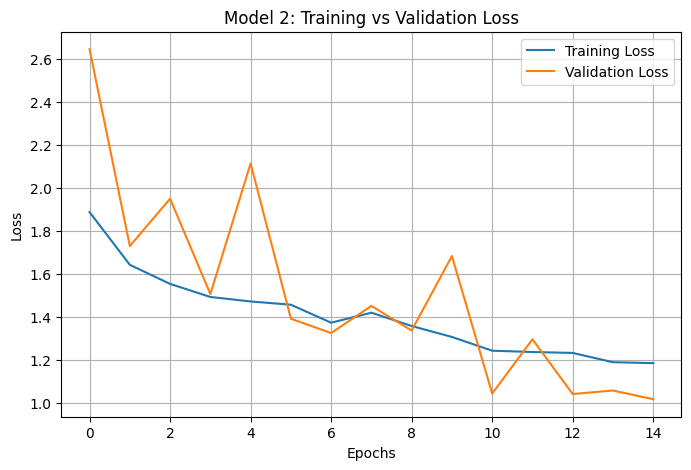

Loss curve saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_2_improved_cnn_results/model_2_loss_curve.png
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 365ms/step - accuracy: 0.5489 - loss: 1.0430
Model 2 Test Loss: 1.043044090270996
Model 2 Test Accuracy: 0.5489022135734558
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 329ms/step
y_true, y_pred, and y_pred_probs saved successfully.
Accuracy: 0.5489021956087824
Macro Precision: 0.3802033901986476
Macro Recall: 0.5089207068818585
Macro F1-score: 0.40224798424261626
Weighted F1-score: 0.5979871491372133
Classification Report:


,precision,recall,f1-score,support
akiec,0.255814,0.666667,0.369748,33.000000
bcc,0.326087,0.294118,0.309278,51.000000
bkl,0.285714,0.363636,0.320000,110.000000
df,0.093023,0.363636,0.148148,11.000000
mel,0.258065,0.571429,0.355556,112.000000
nv,0.942721,0.588674,0.724771,671.000000
vasc,0.500000,0.714286,0.588235,14.000000
accuracy,0.548902,0.548902,0.548902,0.548902
macro avg,0.380203,0.508921,0.402248,1002.000000
weighted avg,0.724544,0.548902,0.597987,1002.000000


Classification report saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_2_improved_cnn_results/model_2_classification_report.csv
Confusion matrix saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_2_improved_cnn_results/model_2_confusion_matrix.csv


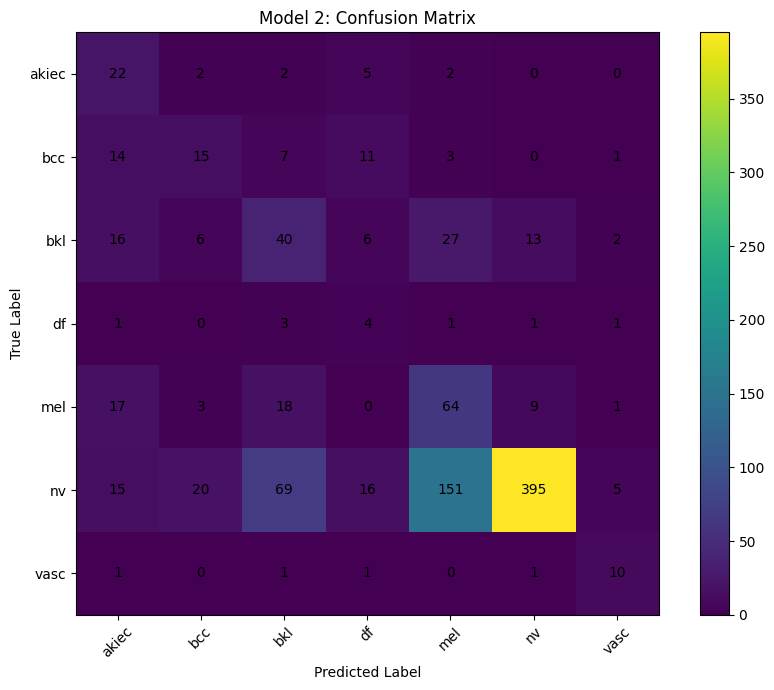

Confusion matrix plot saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_2_improved_cnn_results/model_2_confusion_matrix.png
Metrics saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_2_improved_cnn_results/model_2_metrics.json

Model 1 vs Model 2 Comparison:


,model,test_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Model_1_Simple_CNN_Baseline,0.696607,0.363672,0.230664,0.243511,0.605495
1,Model_2_Improved_CNN,0.548902,0.380203,0.508921,0.402248,0.597987


Comparison saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_2_improved_cnn_results/model_1_vs_model_2_comparison.csv

MODEL 2 IMPROVED CNN COMPLETED SUCCESSFULLY
Test Accuracy: 0.5489022135734558
Macro F1-score: 0.40224798424261626
Weighted F1-score: 0.5979871491372133
All Model 2 results saved in:
/content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_2_improved_cnn_results


In [ ]:
# ============================================================
# MODEL 2: IMPROVED CNN MODEL
# Dataset: HAM10000
# Purpose:
# 1. Improve baseline CNN performance
# 2. Handle class imbalance using class weights
# 3. Add Batch Normalization for stable training
# 4. Use GlobalAveragePooling2D to reduce parameters
# 5. Evaluate and save all important results
# ============================================================

# ------------------------------------------------------------
# 1. Import required libraries
# ------------------------------------------------------------

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    CSVLogger,
    ReduceLROnPlateau
)

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# 2. Create folder to save Model 2 results
# ------------------------------------------------------------

model2_path = os.path.join(base_path, "model_2_improved_cnn_results")
os.makedirs(model2_path, exist_ok=True)

print("Model 2 results will be saved at:")
print(model2_path)

# ------------------------------------------------------------
# 3. Define model settings
# ------------------------------------------------------------

INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, 3)

# Number of output classes
NUM_CLASSES = len(train_generator.class_indices)

# Class labels in correct order
class_labels = list(train_generator.class_indices.keys())

print("Input shape:", INPUT_SHAPE)
print("Number of classes:", NUM_CLASSES)
print("Class labels:", class_labels)

# ------------------------------------------------------------
# 4. Calculate class weights
# ------------------------------------------------------------
# Model 1 predicted mostly the majority class 'nv'.
# Class weights give higher weight to minority classes
# and lower weight to majority classes.

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights_array))

print("\nClass weights:")
print(class_weights)

# Optional: save class weights
class_weights_path = os.path.join(model2_path, "model_2_class_weights.json")

with open(class_weights_path, "w") as f:
    json.dump({str(k): float(v) for k, v in class_weights.items()}, f, indent=4)

print("Class weights saved at:", class_weights_path)

# ------------------------------------------------------------
# 5. Build Improved CNN Model
# ------------------------------------------------------------
# Improvements over Model 1:
# - Input layer explicitly defined
# - BatchNormalization stabilizes training
# - More convolution blocks learn deeper features
# - GlobalAveragePooling2D reduces parameters compared to Flatten
# - Dropout reduces overfitting
# - Lower learning rate improves stable learning

model_2 = Sequential(name="Model_2_Improved_CNN")

# Input layer
model_2.add(Input(shape=INPUT_SHAPE))

# First convolution block
# Learns basic lesion edges, color changes, and boundaries
model_2.add(Conv2D(32, (3, 3), activation="relu", padding="same"))
model_2.add(BatchNormalization())
model_2.add(MaxPooling2D(pool_size=(2, 2)))

# Second convolution block
# Learns texture and small lesion patterns
model_2.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
model_2.add(BatchNormalization())
model_2.add(MaxPooling2D(pool_size=(2, 2)))

# Third convolution block
# Learns deeper lesion structures
model_2.add(Conv2D(128, (3, 3), activation="relu", padding="same"))
model_2.add(BatchNormalization())
model_2.add(MaxPooling2D(pool_size=(2, 2)))

# Fourth convolution block
# Learns high-level disease-related image features
model_2.add(Conv2D(256, (3, 3), activation="relu", padding="same"))
model_2.add(BatchNormalization())
model_2.add(MaxPooling2D(pool_size=(2, 2)))

# Global Average Pooling replaces Flatten
# This reduces parameters and helps avoid overfitting
model_2.add(GlobalAveragePooling2D())

# Dense classification layers
model_2.add(Dense(256, activation="relu"))
model_2.add(Dropout(0.5))

model_2.add(Dense(128, activation="relu"))
model_2.add(Dropout(0.3))

# Output layer
# Softmax gives probabilities for 7 disease classes
model_2.add(Dense(NUM_CLASSES, activation="softmax"))

# ------------------------------------------------------------
# 6. Compile the model
# ------------------------------------------------------------
# Lower learning rate than Model 1 for smoother training.

model_2.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Show model architecture
model_2.summary()

# Save model summary as text file
summary_path = os.path.join(model2_path, "model_2_summary.txt")

with open(summary_path, "w") as f:
    model_2.summary(print_fn=lambda x: f.write(x + "\n"))

print("Model summary saved at:", summary_path)

# ------------------------------------------------------------
# 7. Define callbacks
# ------------------------------------------------------------

# EarlyStopping stops training when validation loss stops improving.
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# ModelCheckpoint saves the best model based on validation loss.
best_model_path = os.path.join(model2_path, "model_2_best.keras")

checkpoint = ModelCheckpoint(
    best_model_path,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# CSVLogger saves epoch-by-epoch training values.
training_log_path = os.path.join(model2_path, "model_2_training_log.csv")

csv_logger = CSVLogger(
    training_log_path,
    append=False
)

# ReduceLROnPlateau lowers learning rate if validation loss stops improving.
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# ------------------------------------------------------------
# 8. Train the improved model
# ------------------------------------------------------------
# class_weight is the key improvement to handle class imbalance.

EPOCHS = 15

history_model_2 = model_2.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint, csv_logger, reduce_lr],
    verbose=1
)

# ------------------------------------------------------------
# 9. Save final trained model
# ------------------------------------------------------------

final_model_path = os.path.join(model2_path, "model_2_final.keras")
model_2.save(final_model_path)

print("Final Model 2 saved at:", final_model_path)
print("Best Model 2 saved at:", best_model_path)

# ------------------------------------------------------------
# 10. Save training history
# ------------------------------------------------------------

history_df = pd.DataFrame(history_model_2.history)

history_csv_path = os.path.join(model2_path, "model_2_history.csv")
history_df.to_csv(history_csv_path, index=False)

print("Training history saved at:", history_csv_path)

# ------------------------------------------------------------
# 11. Plot and save accuracy curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(history_model_2.history["accuracy"], label="Training Accuracy")
plt.plot(history_model_2.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model 2: Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

accuracy_plot_path = os.path.join(model2_path, "model_2_accuracy_curve.png")
plt.savefig(accuracy_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Accuracy curve saved at:", accuracy_plot_path)

# ------------------------------------------------------------
# 12. Plot and save loss curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(history_model_2.history["loss"], label="Training Loss")
plt.plot(history_model_2.history["val_loss"], label="Validation Loss")
plt.title("Model 2: Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

loss_plot_path = os.path.join(model2_path, "model_2_loss_curve.png")
plt.savefig(loss_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Loss curve saved at:", loss_plot_path)

# ------------------------------------------------------------
# 13. Load best model for final evaluation
# ------------------------------------------------------------

best_model_2 = load_model(best_model_path)

# ------------------------------------------------------------
# 14. Evaluate on test data
# ------------------------------------------------------------

test_loss_2, test_accuracy_2 = best_model_2.evaluate(test_generator)

print("Model 2 Test Loss:", test_loss_2)
print("Model 2 Test Accuracy:", test_accuracy_2)

# ------------------------------------------------------------
# 15. Predict test data
# ------------------------------------------------------------
# test_generator shuffle must be False so predictions match true labels.

test_generator.reset()

y_pred_probs_2 = best_model_2.predict(test_generator)

# Convert probability predictions into class indices
y_pred_2 = np.argmax(y_pred_probs_2, axis=1)

# True labels
y_true_2 = test_generator.classes

# ------------------------------------------------------------
# 16. Save y_true, y_pred, and prediction probabilities
# ------------------------------------------------------------

np.save(os.path.join(model2_path, "model_2_y_true.npy"), y_true_2)
np.save(os.path.join(model2_path, "model_2_y_pred.npy"), y_pred_2)
np.save(os.path.join(model2_path, "model_2_y_pred_probs.npy"), y_pred_probs_2)

print("y_true, y_pred, and y_pred_probs saved successfully.")

# ------------------------------------------------------------
# 17. Calculate evaluation metrics
# ------------------------------------------------------------

accuracy_2 = accuracy_score(y_true_2, y_pred_2)
precision_macro_2 = precision_score(y_true_2, y_pred_2, average="macro", zero_division=0)
recall_macro_2 = recall_score(y_true_2, y_pred_2, average="macro", zero_division=0)
f1_macro_2 = f1_score(y_true_2, y_pred_2, average="macro", zero_division=0)

precision_weighted_2 = precision_score(y_true_2, y_pred_2, average="weighted", zero_division=0)
recall_weighted_2 = recall_score(y_true_2, y_pred_2, average="weighted", zero_division=0)
f1_weighted_2 = f1_score(y_true_2, y_pred_2, average="weighted", zero_division=0)

print("Accuracy:", accuracy_2)
print("Macro Precision:", precision_macro_2)
print("Macro Recall:", recall_macro_2)
print("Macro F1-score:", f1_macro_2)
print("Weighted F1-score:", f1_weighted_2)

# ------------------------------------------------------------
# 18. Classification report
# ------------------------------------------------------------

report_dict_2 = classification_report(
    y_true_2,
    y_pred_2,
    target_names=class_labels,
    output_dict=True,
    zero_division=0
)

report_df_2 = pd.DataFrame(report_dict_2).transpose()

report_path = os.path.join(model2_path, "model_2_classification_report.csv")
report_df_2.to_csv(report_path)

print("Classification Report:")
display(report_df_2)

print("Classification report saved at:", report_path)

# ------------------------------------------------------------
# 19. Confusion matrix
# ------------------------------------------------------------

cm_2 = confusion_matrix(y_true_2, y_pred_2)

cm_df_2 = pd.DataFrame(
    cm_2,
    index=class_labels,
    columns=class_labels
)

cm_csv_path = os.path.join(model2_path, "model_2_confusion_matrix.csv")
cm_df_2.to_csv(cm_csv_path)

print("Confusion matrix saved at:", cm_csv_path)

# Plot confusion matrix
plt.figure(figsize=(9, 7))
plt.imshow(cm_2, interpolation="nearest")
plt.title("Model 2: Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_labels))
plt.xticks(tick_marks, class_labels, rotation=45)
plt.yticks(tick_marks, class_labels)

for i in range(cm_2.shape[0]):
    for j in range(cm_2.shape[1]):
        plt.text(j, i, cm_2[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

cm_plot_path = os.path.join(model2_path, "model_2_confusion_matrix.png")
plt.savefig(cm_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix plot saved at:", cm_plot_path)

# ------------------------------------------------------------
# 20. Save final metrics as JSON
# ------------------------------------------------------------

metrics_2 = {
    "model_name": "Model_2_Improved_CNN",
    "test_loss": float(test_loss_2),
    "test_accuracy": float(test_accuracy_2),
    "accuracy_score": float(accuracy_2),
    "precision_macro": float(precision_macro_2),
    "recall_macro": float(recall_macro_2),
    "f1_macro": float(f1_macro_2),
    "precision_weighted": float(precision_weighted_2),
    "recall_weighted": float(recall_weighted_2),
    "f1_weighted": float(f1_weighted_2),
    "class_labels": class_labels,
    "class_weights": {str(k): float(v) for k, v in class_weights.items()},
    "best_model_path": best_model_path,
    "final_model_path": final_model_path
}

metrics_path = os.path.join(model2_path, "model_2_metrics.json")

with open(metrics_path, "w") as f:
    json.dump(metrics_2, f, indent=4)

print("Metrics saved at:", metrics_path)

# ------------------------------------------------------------
# 21. Compare Model 1 and Model 2 if Model 1 metrics exist
# ------------------------------------------------------------

model1_metrics_path = os.path.join(
    base_path,
    "model_1_baseline_results",
    "model_1_metrics.json"
)

if os.path.exists(model1_metrics_path):
    with open(model1_metrics_path, "r") as f:
        metrics_1 = json.load(f)

    comparison_df = pd.DataFrame([
        {
            "model": metrics_1["model_name"],
            "test_accuracy": metrics_1["test_accuracy"],
            "macro_precision": metrics_1["precision_macro"],
            "macro_recall": metrics_1["recall_macro"],
            "macro_f1": metrics_1["f1_macro"],
            "weighted_f1": metrics_1["f1_weighted"]
        },
        {
            "model": metrics_2["model_name"],
            "test_accuracy": metrics_2["test_accuracy"],
            "macro_precision": metrics_2["precision_macro"],
            "macro_recall": metrics_2["recall_macro"],
            "macro_f1": metrics_2["f1_macro"],
            "weighted_f1": metrics_2["f1_weighted"]
        }
    ])

    comparison_path = os.path.join(model2_path, "model_1_vs_model_2_comparison.csv")
    comparison_df.to_csv(comparison_path, index=False)

    print("\nModel 1 vs Model 2 Comparison:")
    display(comparison_df)

    print("Comparison saved at:", comparison_path)

# ------------------------------------------------------------
# 22. Final summary
# ------------------------------------------------------------

print("\nMODEL 2 IMPROVED CNN COMPLETED SUCCESSFULLY")
print("Test Accuracy:", test_accuracy_2)
print("Macro F1-score:", f1_macro_2)
print("Weighted F1-score:", f1_weighted_2)
print("All Model 2 results saved in:")
print(model2_path)

MODEL 3: MobileNetV2 TRANSFER LEARNING

Model 3 results will be saved at:
/content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3_mobilenetv2_results
Training samples: 7010
Validation samples: 2003
Testing samples: 1002
Input shape: (224, 224, 3)
Found 7010 validated image filenames belonging to 7 classes.
Found 2003 validated image filenames belonging to 7 classes.
Found 1002 validated image filenames belonging to 7 classes.
Number of classes: 7
Class labels: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Class indices: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}

Class weights:
{0: np.float64(4.37305053025577), 1: np.float64(2.7817460317460316), 2: np.float64(1.3022478172023035), 3: np.float64(12.36331569664903), 4: np.float64(1.285530900421786), 5: np.float64(0.21338772031292808), 6: np.float64(10.115440115440116)}
Class weights saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3_mobilenetv2_results/model_3_class_weights.json
9406464/9406464 ━━━━━━━

Model: "Model_3_MobileNetV2_Transfer_Learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,719 (9.99 MB)

 Trainable params: 361,735 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Model summary saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3_mobilenetv2_results/model_3_summary.txt
Epoch 1/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 813ms/step - accuracy: 0.2253 - loss: 2.2830
Epoch 1: val_loss improved from None to 1.42475, saving model to /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3_mobilenetv2_results/model_3_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3_mobilenetv2_results/model_3_best.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 241s 1s/step - accuracy: 0.2243 - loss: 2.0481 - val_accuracy: 0.5986 - val_loss: 1.4248 - learning_rate: 1.0000e-04
Epoch 2/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 738ms/step - accuracy: 0.3290 - loss: 1.7323
Epoch 2: val_loss improved from 1.42475 to 1.29356, saving model to /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3_mobilenetv2_results/model_3_best.keras

Epoch 2: finished saving model to /content/drive

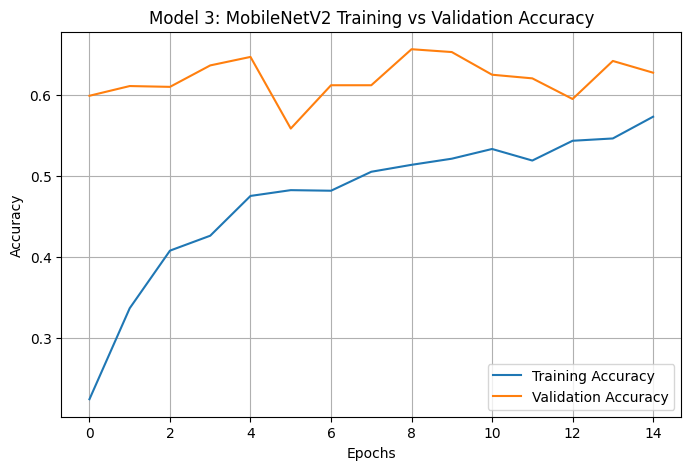

Accuracy curve saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3_mobilenetv2_results/model_3_accuracy_curve.png


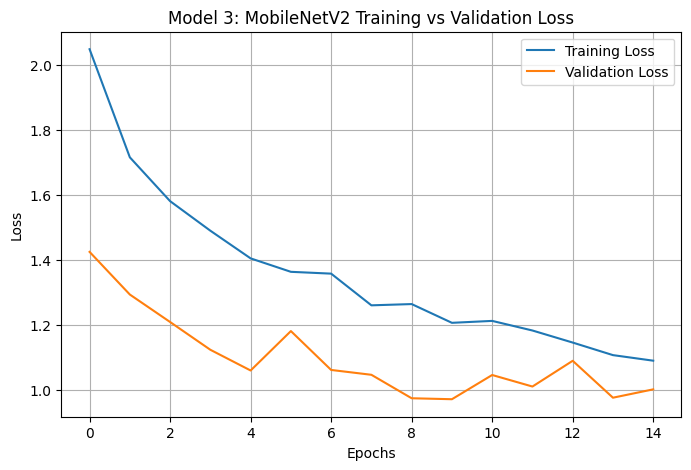

Loss curve saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3_mobilenetv2_results/model_3_loss_curve.png
32/32 ━━━━━━━━━━━━━━━━━━━━ 29s 690ms/step - accuracy: 0.6367 - loss: 0.9984
Model 3 Test Loss: 0.9983803629875183
Model 3 Test Accuracy: 0.6367265582084656
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 484ms/step
y_true, y_pred, and y_pred_probs saved successfully.
Accuracy: 0.6367265469061876
Macro Precision: 0.38417478265345206
Macro Recall: 0.5269577875859733
Macro F1-score: 0.4197708365452416
Weighted F1-score: 0.6740960153575986
Classification Report:


,precision,recall,f1-score,support
akiec,0.227848,0.545455,0.321429,33.000000
bcc,0.358974,0.549020,0.434109,51.000000
bkl,0.391753,0.345455,0.367150,110.000000
df,0.128205,0.454545,0.200000,11.000000
mel,0.327485,0.500000,0.395760,112.000000
nv,0.947266,0.722802,0.819949,671.000000
vasc,0.307692,0.571429,0.400000,14.000000
accuracy,0.636727,0.636727,0.636727,0.636727
macro avg,0.384175,0.526958,0.419771,1002.000000
weighted avg,0.745440,0.636727,0.674096,1002.000000


Classification report saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3_mobilenetv2_results/model_3_classification_report.csv
Confusion matrix saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3_mobilenetv2_results/model_3_confusion_matrix.csv


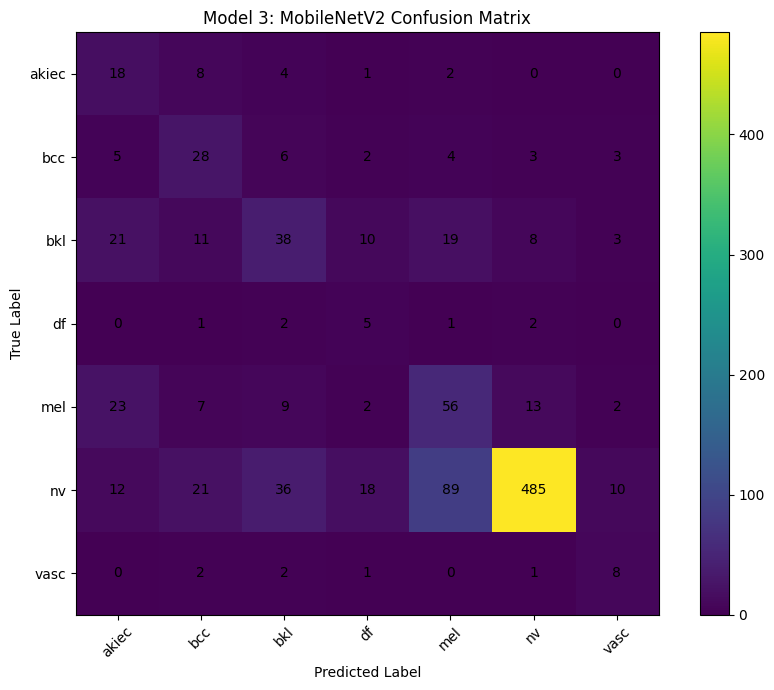

Confusion matrix plot saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3_mobilenetv2_results/model_3_confusion_matrix.png
Metrics saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3_mobilenetv2_results/model_3_metrics.json

Model 1 vs Model 2 vs Model 3 Comparison:


,model,test_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Model_1_Simple_CNN_Baseline,0.696607,0.363672,0.230664,0.243511,0.605495
1,Model_2_Improved_CNN,0.548902,0.380203,0.508921,0.402248,0.597987
2,Model_3_MobileNetV2_Transfer_Learning,0.636727,0.384175,0.526958,0.419771,0.674096


Comparison saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3_mobilenetv2_results/model_1_2_3_comparison.csv

Current Best Model:
{
    "best_model_name": "Model_3_MobileNetV2_Transfer_Learning",
    "selection_metric": "macro_f1",
    "best_macro_f1": 0.4197708365452416,
    "test_accuracy": 0.6367265582084656
}
Best model info saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3_mobilenetv2_results/current_best_model_info.json

MODEL 3 MobileNetV2 COMPLETED SUCCESSFULLY
Test Accuracy: 0.6367265582084656
Macro F1-score: 0.4197708365452416
Weighted F1-score: 0.6740960153575986
All Model 3 results saved in:
/content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3_mobilenetv2_results


In [ ]:
# ============================================================
# MODEL 3: MobileNetV2 TRANSFER LEARNING
# Dataset: HAM10000
# Purpose:
# 1. Use pretrained MobileNetV2 for stronger feature extraction
# 2. Handle class imbalance using class weights
# 3. Train, evaluate, and save all results
# 4. Compare Model 1, Model 2, and Model 3
# ============================================================

# ------------------------------------------------------------
# 1. Import required libraries
# ------------------------------------------------------------

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    CSVLogger,
    ReduceLROnPlateau
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# 2. Create folder to save Model 3 results
# ------------------------------------------------------------

model3_path = os.path.join(base_path, "model_3_mobilenetv2_results")
os.makedirs(model3_path, exist_ok=True)

print("Model 3 results will be saved at:")
print(model3_path)

# ------------------------------------------------------------
# 3. Load train, validation, and test CSV files
# ------------------------------------------------------------
# This makes the code independent.
# Even if train_df, val_df, test_df are not in memory, this will load them.

split_path = os.path.join(base_path, "splits")

train_df = pd.read_csv(os.path.join(split_path, "train.csv"))
val_df = pd.read_csv(os.path.join(split_path, "val.csv"))
test_df = pd.read_csv(os.path.join(split_path, "test.csv"))

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Testing samples:", len(test_df))

# ------------------------------------------------------------
# 4. Define image and model settings
# ------------------------------------------------------------

IMG_SIZE = 224
BATCH_SIZE = 32
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, 3)

print("Input shape:", INPUT_SHAPE)

# ------------------------------------------------------------
# 5. Create MobileNetV2 image generators
# ------------------------------------------------------------
# Important:
# MobileNetV2 uses preprocess_input.
# Do NOT use rescale=1./255 here.
# preprocess_input converts image pixels into the format expected by MobileNetV2.

train_datagen_mobilenet = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_test_datagen_mobilenet = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator_mobilenet = train_datagen_mobilenet.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="dx",
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator_mobilenet = val_test_datagen_mobilenet.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="dx",
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator_mobilenet = val_test_datagen_mobilenet.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="dx",
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# Number of classes and labels
NUM_CLASSES = len(train_generator_mobilenet.class_indices)
class_labels = list(train_generator_mobilenet.class_indices.keys())

print("Number of classes:", NUM_CLASSES)
print("Class labels:", class_labels)
print("Class indices:", train_generator_mobilenet.class_indices)

# ------------------------------------------------------------
# 6. Calculate class weights
# ------------------------------------------------------------
# Class weights help minority classes.
# Majority class gets lower weight, minority classes get higher weight.

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator_mobilenet.classes),
    y=train_generator_mobilenet.classes
)

class_weights = dict(enumerate(class_weights_array))

print("\nClass weights:")
print(class_weights)

# Save class weights
class_weights_path = os.path.join(model3_path, "model_3_class_weights.json")

with open(class_weights_path, "w") as f:
    json.dump({str(k): float(v) for k, v in class_weights.items()}, f, indent=4)

print("Class weights saved at:", class_weights_path)

# ------------------------------------------------------------
# 7. Build MobileNetV2 transfer learning model
# ------------------------------------------------------------
# MobileNetV2 is pretrained on ImageNet.
# We remove its original classification head and add our own head.
# The base model is frozen first, so only the new classifier trains.

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=INPUT_SHAPE
)

# Freeze pretrained layers
base_model.trainable = False

# Input layer
inputs = Input(shape=INPUT_SHAPE)

# Pass image through MobileNetV2 base
x = base_model(inputs, training=False)

# Convert feature maps into vector
x = GlobalAveragePooling2D()(x)

# Custom classification head
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)

x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

# Output layer for 7 classes
outputs = Dense(NUM_CLASSES, activation="softmax")(x)

model_3 = Model(inputs, outputs, name="Model_3_MobileNetV2_Transfer_Learning")

# ------------------------------------------------------------
# 8. Compile the model
# ------------------------------------------------------------
# Low learning rate is used because we are training a pretrained model head.

model_3.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_3.summary()

# Save model summary
summary_path = os.path.join(model3_path, "model_3_summary.txt")

with open(summary_path, "w") as f:
    model_3.summary(print_fn=lambda x: f.write(x + "\n"))

print("Model summary saved at:", summary_path)

# ------------------------------------------------------------
# 9. Define callbacks
# ------------------------------------------------------------

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

best_model_path = os.path.join(model3_path, "model_3_best.keras")

checkpoint = ModelCheckpoint(
    best_model_path,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

training_log_path = os.path.join(model3_path, "model_3_training_log.csv")

csv_logger = CSVLogger(
    training_log_path,
    append=False
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# ------------------------------------------------------------
# 10. Train MobileNetV2 model
# ------------------------------------------------------------
# class_weight is used because HAM10000 is imbalanced.

EPOCHS = 15

history_model_3 = model_3.fit(
    train_generator_mobilenet,
    validation_data=val_generator_mobilenet,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint, csv_logger, reduce_lr],
    verbose=1
)

# ------------------------------------------------------------
# 11. Save final trained model
# ------------------------------------------------------------

final_model_path = os.path.join(model3_path, "model_3_final.keras")
model_3.save(final_model_path)

print("Final Model 3 saved at:", final_model_path)
print("Best Model 3 saved at:", best_model_path)

# ------------------------------------------------------------
# 12. Save training history
# ------------------------------------------------------------

history_df = pd.DataFrame(history_model_3.history)

history_csv_path = os.path.join(model3_path, "model_3_history.csv")
history_df.to_csv(history_csv_path, index=False)

print("Training history saved at:", history_csv_path)

# ------------------------------------------------------------
# 13. Plot and save accuracy curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(history_model_3.history["accuracy"], label="Training Accuracy")
plt.plot(history_model_3.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model 3: MobileNetV2 Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

accuracy_plot_path = os.path.join(model3_path, "model_3_accuracy_curve.png")
plt.savefig(accuracy_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Accuracy curve saved at:", accuracy_plot_path)

# ------------------------------------------------------------
# 14. Plot and save loss curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(history_model_3.history["loss"], label="Training Loss")
plt.plot(history_model_3.history["val_loss"], label="Validation Loss")
plt.title("Model 3: MobileNetV2 Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

loss_plot_path = os.path.join(model3_path, "model_3_loss_curve.png")
plt.savefig(loss_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Loss curve saved at:", loss_plot_path)

# ------------------------------------------------------------
# 15. Load best model for final evaluation
# ------------------------------------------------------------

best_model_3 = load_model(best_model_path)

# ------------------------------------------------------------
# 16. Evaluate on test data
# ------------------------------------------------------------

test_loss_3, test_accuracy_3 = best_model_3.evaluate(test_generator_mobilenet)

print("Model 3 Test Loss:", test_loss_3)
print("Model 3 Test Accuracy:", test_accuracy_3)

# ------------------------------------------------------------
# 17. Predict test data
# ------------------------------------------------------------
# test_generator_mobilenet shuffle is False, so predictions align with true labels.

test_generator_mobilenet.reset()

y_pred_probs_3 = best_model_3.predict(test_generator_mobilenet)

# Convert probabilities to predicted class indices
y_pred_3 = np.argmax(y_pred_probs_3, axis=1)

# True labels
y_true_3 = test_generator_mobilenet.classes

# ------------------------------------------------------------
# 18. Save y_true, y_pred, and probabilities
# ------------------------------------------------------------

np.save(os.path.join(model3_path, "model_3_y_true.npy"), y_true_3)
np.save(os.path.join(model3_path, "model_3_y_pred.npy"), y_pred_3)
np.save(os.path.join(model3_path, "model_3_y_pred_probs.npy"), y_pred_probs_3)

print("y_true, y_pred, and y_pred_probs saved successfully.")

# ------------------------------------------------------------
# 19. Calculate evaluation metrics
# ------------------------------------------------------------

accuracy_3 = accuracy_score(y_true_3, y_pred_3)

precision_macro_3 = precision_score(
    y_true_3, y_pred_3, average="macro", zero_division=0
)

recall_macro_3 = recall_score(
    y_true_3, y_pred_3, average="macro", zero_division=0
)

f1_macro_3 = f1_score(
    y_true_3, y_pred_3, average="macro", zero_division=0
)

precision_weighted_3 = precision_score(
    y_true_3, y_pred_3, average="weighted", zero_division=0
)

recall_weighted_3 = recall_score(
    y_true_3, y_pred_3, average="weighted", zero_division=0
)

f1_weighted_3 = f1_score(
    y_true_3, y_pred_3, average="weighted", zero_division=0
)

print("Accuracy:", accuracy_3)
print("Macro Precision:", precision_macro_3)
print("Macro Recall:", recall_macro_3)
print("Macro F1-score:", f1_macro_3)
print("Weighted F1-score:", f1_weighted_3)

# ------------------------------------------------------------
# 20. Classification report
# ------------------------------------------------------------

report_dict_3 = classification_report(
    y_true_3,
    y_pred_3,
    target_names=class_labels,
    output_dict=True,
    zero_division=0
)

report_df_3 = pd.DataFrame(report_dict_3).transpose()

report_path = os.path.join(model3_path, "model_3_classification_report.csv")
report_df_3.to_csv(report_path)

print("Classification Report:")
display(report_df_3)

print("Classification report saved at:", report_path)

# ------------------------------------------------------------
# 21. Confusion matrix
# ------------------------------------------------------------

cm_3 = confusion_matrix(y_true_3, y_pred_3)

cm_df_3 = pd.DataFrame(
    cm_3,
    index=class_labels,
    columns=class_labels
)

cm_csv_path = os.path.join(model3_path, "model_3_confusion_matrix.csv")
cm_df_3.to_csv(cm_csv_path)

print("Confusion matrix saved at:", cm_csv_path)

# Plot confusion matrix
plt.figure(figsize=(9, 7))
plt.imshow(cm_3, interpolation="nearest")
plt.title("Model 3: MobileNetV2 Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_labels))
plt.xticks(tick_marks, class_labels, rotation=45)
plt.yticks(tick_marks, class_labels)

for i in range(cm_3.shape[0]):
    for j in range(cm_3.shape[1]):
        plt.text(j, i, cm_3[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

cm_plot_path = os.path.join(model3_path, "model_3_confusion_matrix.png")
plt.savefig(cm_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix plot saved at:", cm_plot_path)

# ------------------------------------------------------------
# 22. Save final metrics as JSON
# ------------------------------------------------------------

metrics_3 = {
    "model_name": "Model_3_MobileNetV2_Transfer_Learning",
    "test_loss": float(test_loss_3),
    "test_accuracy": float(test_accuracy_3),
    "accuracy_score": float(accuracy_3),
    "precision_macro": float(precision_macro_3),
    "recall_macro": float(recall_macro_3),
    "f1_macro": float(f1_macro_3),
    "precision_weighted": float(precision_weighted_3),
    "recall_weighted": float(recall_weighted_3),
    "f1_weighted": float(f1_weighted_3),
    "class_labels": class_labels,
    "class_weights": {str(k): float(v) for k, v in class_weights.items()},
    "best_model_path": best_model_path,
    "final_model_path": final_model_path
}

metrics_path = os.path.join(model3_path, "model_3_metrics.json")

with open(metrics_path, "w") as f:
    json.dump(metrics_3, f, indent=4)

print("Metrics saved at:", metrics_path)

# ------------------------------------------------------------
# 23. Compare Model 1, Model 2, and Model 3
# ------------------------------------------------------------

comparison_rows = []

# Load Model 1 metrics if available
model1_metrics_path = os.path.join(
    base_path,
    "model_1_baseline_results",
    "model_1_metrics.json"
)

if os.path.exists(model1_metrics_path):
    with open(model1_metrics_path, "r") as f:
        metrics_1 = json.load(f)

    comparison_rows.append({
        "model": metrics_1["model_name"],
        "test_accuracy": metrics_1["test_accuracy"],
        "macro_precision": metrics_1["precision_macro"],
        "macro_recall": metrics_1["recall_macro"],
        "macro_f1": metrics_1["f1_macro"],
        "weighted_f1": metrics_1["f1_weighted"]
    })

# Load Model 2 metrics if available
model2_metrics_path = os.path.join(
    base_path,
    "model_2_improved_cnn_results",
    "model_2_metrics.json"
)

if os.path.exists(model2_metrics_path):
    with open(model2_metrics_path, "r") as f:
        metrics_2 = json.load(f)

    comparison_rows.append({
        "model": metrics_2["model_name"],
        "test_accuracy": metrics_2["test_accuracy"],
        "macro_precision": metrics_2["precision_macro"],
        "macro_recall": metrics_2["recall_macro"],
        "macro_f1": metrics_2["f1_macro"],
        "weighted_f1": metrics_2["f1_weighted"]
    })

# Add Model 3 metrics
comparison_rows.append({
    "model": metrics_3["model_name"],
    "test_accuracy": metrics_3["test_accuracy"],
    "macro_precision": metrics_3["precision_macro"],
    "macro_recall": metrics_3["recall_macro"],
    "macro_f1": metrics_3["f1_macro"],
    "weighted_f1": metrics_3["f1_weighted"]
})

comparison_df = pd.DataFrame(comparison_rows)

comparison_path = os.path.join(model3_path, "model_1_2_3_comparison.csv")
comparison_df.to_csv(comparison_path, index=False)

print("\nModel 1 vs Model 2 vs Model 3 Comparison:")
display(comparison_df)

print("Comparison saved at:", comparison_path)

# ------------------------------------------------------------
# 24. Select current best model using macro F1-score
# ------------------------------------------------------------
# For imbalanced medical data, macro F1 is more useful than accuracy alone.

best_row = comparison_df.sort_values(by="macro_f1", ascending=False).iloc[0]

best_model_info = {
    "best_model_name": best_row["model"],
    "selection_metric": "macro_f1",
    "best_macro_f1": float(best_row["macro_f1"]),
    "test_accuracy": float(best_row["test_accuracy"])
}

best_info_path = os.path.join(model3_path, "current_best_model_info.json")

with open(best_info_path, "w") as f:
    json.dump(best_model_info, f, indent=4)

print("\nCurrent Best Model:")
print(json.dumps(best_model_info, indent=4))
print("Best model info saved at:", best_info_path)

# ------------------------------------------------------------
# 25. Final summary
# ------------------------------------------------------------

print("\nMODEL 3 MobileNetV2 COMPLETED SUCCESSFULLY")
print("Test Accuracy:", test_accuracy_3)
print("Macro F1-score:", f1_macro_3)
print("Weighted F1-score:", f1_weighted_3)
print("All Model 3 results saved in:")
print(model3_path)

MODEL 3B: FINE-TUNED MobileNetV2

Loading Model 3 from:
/content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3_mobilenetv2_results/model_3_best.keras

Fine-tuned Model 3B results will be saved at:
/content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3b_mobilenetv2_finetuned_results

Training samples: 7010
Validation samples: 2003
Testing samples: 1002
Found 7010 validated image filenames belonging to 7 classes.
Found 2003 validated image filenames belonging to 7 classes.
Found 1002 validated image filenames belonging to 7 classes.

Number of classes: 7
Class labels: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Class indices: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}

Class weights:
{0: np.float64(4.37305053025577), 1: np.float64(2.7817460317460316), 2: np.float64(1.3022478172023035), 3: np.float64(12.36331569664903), 4: np.float64(1.285530900421786), 5: np.float64(0.21338772031292808), 6: np.float64(10.115440115440116)}
Class weights saved at: /content/d

Model: "Model_3_MobileNetV2_Transfer_Learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,719 (9.99 MB)

 Trainable params: 2,025,095 (7.73 MB)

 Non-trainable params: 594,624 (2.27 MB)

Model summary saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3b_mobilenetv2_finetuned_results/model_3b_summary.txt
Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 742ms/step - accuracy: 0.5188 - loss: 1.3038
Epoch 1: val_loss improved from None to 1.03363, saving model to /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3b_mobilenetv2_finetuned_results/model_3b_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3b_mobilenetv2_finetuned_results/model_3b_best.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 210s 884ms/step - accuracy: 0.5153 - loss: 1.2351 - val_accuracy: 0.6231 - val_loss: 1.0336 - learning_rate: 1.0000e-05
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 712ms/step - accuracy: 0.5252 - loss: 1.2028
Epoch 2: val_loss did not improve from 1.03363
220/220 ━━━━━━━━━━━━━━━━━━━━ 178s 808ms/step - accuracy: 0.5307 - loss: 1.1862 - val_accuracy: 0.5986 - val_loss: 1.0509 - learning_rate: 1.

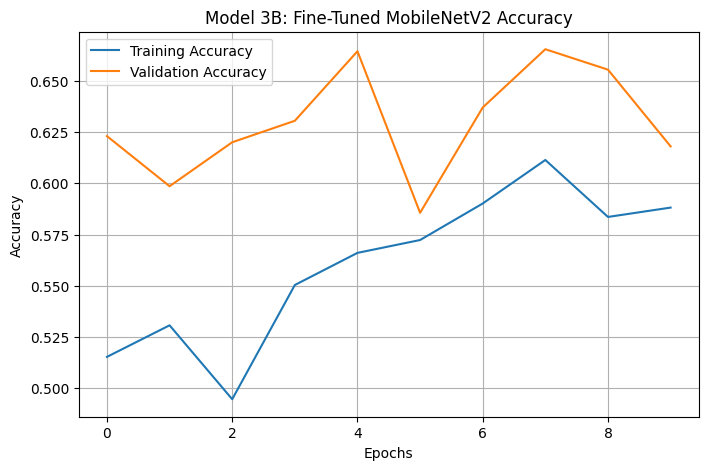

Accuracy curve saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3b_mobilenetv2_finetuned_results/model_3b_accuracy_curve.png


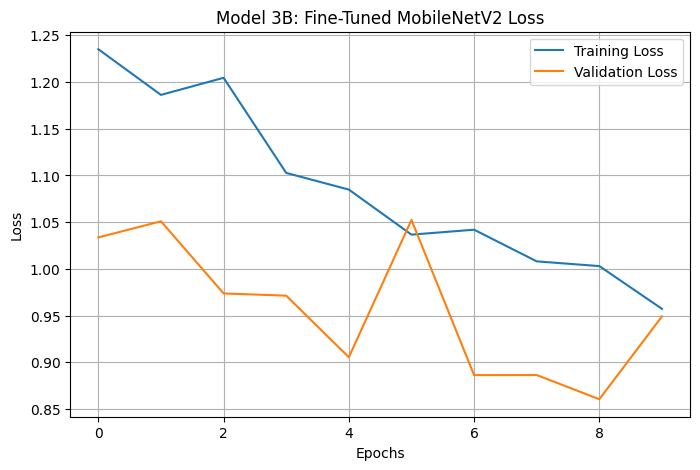

Loss curve saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3b_mobilenetv2_finetuned_results/model_3b_loss_curve.png
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 416ms/step - accuracy: 0.6447 - loss: 0.8930
Model 3B Test Loss: 0.8930072784423828
Model 3B Test Accuracy: 0.6447106003761292
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 469ms/step
y_true, y_pred, and y_pred_probs saved successfully.
Accuracy: 0.6447105788423154
Macro Precision: 0.4756792129750772
Macro Recall: 0.5517560004627783
Macro F1-score: 0.48329414323821035
Weighted F1-score: 0.6825288508057836
Classification Report:


,precision,recall,f1-score,support
akiec,0.320000,0.484848,0.385542,33.000000
bcc,0.642857,0.352941,0.455696,51.000000
bkl,0.413043,0.518182,0.459677,110.000000
df,0.272727,0.545455,0.363636,11.000000
mel,0.273810,0.616071,0.379121,112.000000
nv,0.957317,0.701937,0.809974,671.000000
vasc,0.450000,0.642857,0.529412,14.000000
accuracy,0.644711,0.644711,0.644711,0.644711
macro avg,0.475679,0.551756,0.483294,1002.000000
weighted avg,0.769568,0.644711,0.682529,1002.000000


Classification report saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3b_mobilenetv2_finetuned_results/model_3b_classification_report.csv
Confusion matrix saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3b_mobilenetv2_finetuned_results/model_3b_confusion_matrix.csv


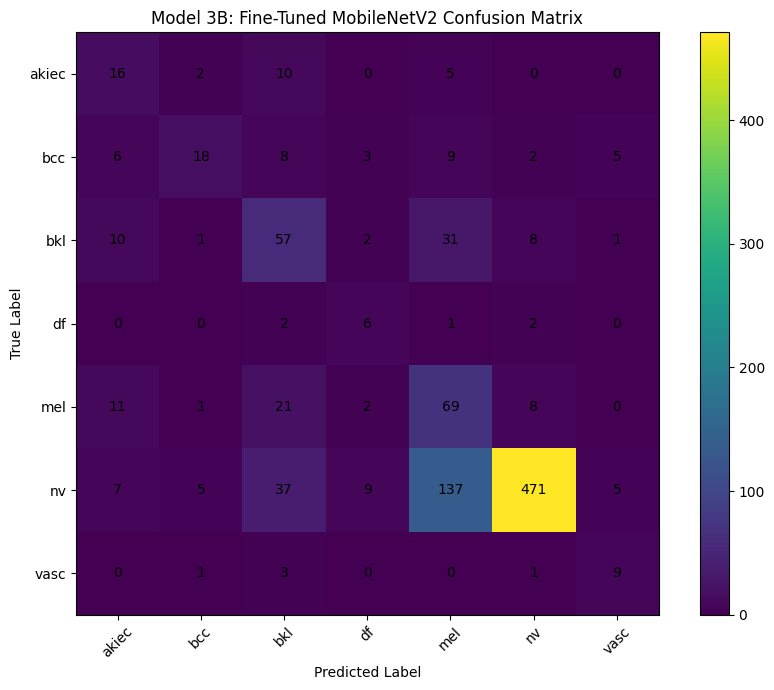

Confusion matrix plot saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3b_mobilenetv2_finetuned_results/model_3b_confusion_matrix.png
Metrics saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3b_mobilenetv2_finetuned_results/model_3b_metrics.json

Model Comparison:


,model_name,test_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,best_model_path
3,Model_3B_MobileNetV2_Fine_Tuned,0.644711,0.475679,0.551756,0.483294,0.682529,/content/drive/MyDrive/DeepLearningProject/HAM...
2,Model_3_MobileNetV2_Transfer_Learning,0.636727,0.384175,0.526958,0.419771,0.674096,/content/drive/MyDrive/DeepLearningProject/HAM...
1,Model_2_Improved_CNN,0.548902,0.380203,0.508921,0.402248,0.597987,/content/drive/MyDrive/DeepLearningProject/HAM...
0,Model_1_Simple_CNN_Baseline,0.696607,0.363672,0.230664,0.243511,0.605495,/content/drive/MyDrive/DeepLearningProject/HAM...


Comparison saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3b_mobilenetv2_finetuned_results/model_1_2_3_3b_comparison.csv

Current Best Model After Fine-Tuning:
{
    "best_model_name": "Model_3B_MobileNetV2_Fine_Tuned",
    "selection_metric": "macro_f1",
    "best_macro_f1": 0.48329414323821035,
    "test_accuracy": 0.6447106003761292,
    "best_model_path": "/content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3b_mobilenetv2_finetuned_results/model_3b_best.keras"
}
Best model info saved at: /content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3b_mobilenetv2_finetuned_results/current_best_model_info_after_finetuning.json

MODEL 3B FINE-TUNED MobileNetV2 COMPLETED SUCCESSFULLY
Test Accuracy: 0.6447106003761292
Macro F1-score: 0.48329414323821035
Weighted F1-score: 0.6825288508057836
All Model 3B results saved in:
/content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3b_mobilenetv2_finetuned_results


In [ ]:
# ============================================================
# MODEL 3B: FINE-TUNED MobileNetV2
# Dataset: HAM10000
# Purpose:
# 1. Load the best saved MobileNetV2 model from Model 3
# 2. Unfreeze the last layers of MobileNetV2
# 3. Keep BatchNormalization layers frozen
# 4. Train with very low learning rate
# 5. Evaluate, save results, and compare with previous models
# ============================================================

# ------------------------------------------------------------
# 1. Import required libraries
# ------------------------------------------------------------

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    CSVLogger,
    ReduceLROnPlateau
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# 2. Define paths
# ------------------------------------------------------------

base_path = "/content/drive/MyDrive/DeepLearningProject/HAM10000/extracted"

model3_path = os.path.join(base_path, "model_3_mobilenetv2_results")
model3_best_path = os.path.join(model3_path, "model_3_best.keras")

model3b_path = os.path.join(base_path, "model_3b_mobilenetv2_finetuned_results")
os.makedirs(model3b_path, exist_ok=True)

print("Loading Model 3 from:")
print(model3_best_path)

print("\nFine-tuned Model 3B results will be saved at:")
print(model3b_path)

# ------------------------------------------------------------
# 3. Load train, validation, and test CSV files
# ------------------------------------------------------------

split_path = os.path.join(base_path, "splits")

train_df = pd.read_csv(os.path.join(split_path, "train.csv"))
val_df = pd.read_csv(os.path.join(split_path, "val.csv"))
test_df = pd.read_csv(os.path.join(split_path, "test.csv"))

print("\nTraining samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Testing samples:", len(test_df))

# ------------------------------------------------------------
# 4. Create MobileNetV2 generators
# ------------------------------------------------------------
# Important:
# Use preprocess_input for MobileNetV2.
# Do not use rescale=1./255 here.

IMG_SIZE = 224
BATCH_SIZE = 32
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, 3)

train_datagen_mobilenet = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_test_datagen_mobilenet = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator_mobilenet = train_datagen_mobilenet.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="dx",
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator_mobilenet = val_test_datagen_mobilenet.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="dx",
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator_mobilenet = val_test_datagen_mobilenet.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="dx",
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

NUM_CLASSES = len(train_generator_mobilenet.class_indices)
class_labels = list(train_generator_mobilenet.class_indices.keys())

print("\nNumber of classes:", NUM_CLASSES)
print("Class labels:", class_labels)
print("Class indices:", train_generator_mobilenet.class_indices)

# ------------------------------------------------------------
# 5. Calculate class weights
# ------------------------------------------------------------
# Class weights are used again because HAM10000 is imbalanced.

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator_mobilenet.classes),
    y=train_generator_mobilenet.classes
)

class_weights = dict(enumerate(class_weights_array))

print("\nClass weights:")
print(class_weights)

class_weights_path = os.path.join(model3b_path, "model_3b_class_weights.json")

with open(class_weights_path, "w") as f:
    json.dump({str(k): float(v) for k, v in class_weights.items()}, f, indent=4)

print("Class weights saved at:", class_weights_path)

# ------------------------------------------------------------
# 6. Load best MobileNetV2 model
# ------------------------------------------------------------

model_3b = load_model(model3_best_path)

print("\nLoaded Model 3 successfully.")

# ------------------------------------------------------------
# 7. Unfreeze selected MobileNetV2 layers for fine-tuning
# ------------------------------------------------------------
# Fine-tuning means we allow some upper layers of the pretrained model to update.
# We do NOT unfreeze all layers because that may overfit or damage pretrained features.
# We keep BatchNormalization layers frozen for stable training.

# Find MobileNetV2 base model inside loaded model
base_mobilenet = None

for layer in model_3b.layers:
    if "mobilenetv2" in layer.name.lower():
        base_mobilenet = layer
        break

if base_mobilenet is None:
    raise ValueError("MobileNetV2 base model not found inside loaded model.")

# Unfreeze the base model
base_mobilenet.trainable = True

# Number of last layers to fine-tune
FINE_TUNE_LAST_N_LAYERS = 40

# Freeze earlier layers, unfreeze only last N layers
for layer in base_mobilenet.layers[:-FINE_TUNE_LAST_N_LAYERS]:
    layer.trainable = False

for layer in base_mobilenet.layers[-FINE_TUNE_LAST_N_LAYERS:]:
    # Keep BatchNormalization frozen
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

# Check trainable layers
trainable_count = sum([1 for layer in base_mobilenet.layers if layer.trainable])
non_trainable_count = sum([1 for layer in base_mobilenet.layers if not layer.trainable])

print("\nMobileNetV2 fine-tuning setup:")
print("Fine-tuning last layers:", FINE_TUNE_LAST_N_LAYERS)
print("Trainable layers in MobileNetV2:", trainable_count)
print("Non-trainable layers in MobileNetV2:", non_trainable_count)

# ------------------------------------------------------------
# 8. Compile fine-tuned model
# ------------------------------------------------------------
# Very low learning rate is important for fine-tuning.
# A high learning rate can destroy pretrained features.

model_3b.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_3b.summary()

# Save model summary
summary_path = os.path.join(model3b_path, "model_3b_summary.txt")

with open(summary_path, "w") as f:
    model_3b.summary(print_fn=lambda x: f.write(x + "\n"))

print("Model summary saved at:", summary_path)

# ------------------------------------------------------------
# 9. Define callbacks
# ------------------------------------------------------------

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

best_model_path = os.path.join(model3b_path, "model_3b_best.keras")

checkpoint = ModelCheckpoint(
    best_model_path,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

training_log_path = os.path.join(model3b_path, "model_3b_training_log.csv")

csv_logger = CSVLogger(
    training_log_path,
    append=False
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# ------------------------------------------------------------
# 10. Fine-tune model
# ------------------------------------------------------------
# Use fewer epochs because this is fine-tuning, not training from scratch.

EPOCHS_FINE_TUNE = 10

history_model_3b = model_3b.fit(
    train_generator_mobilenet,
    validation_data=val_generator_mobilenet,
    epochs=EPOCHS_FINE_TUNE,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint, csv_logger, reduce_lr],
    verbose=1
)

# ------------------------------------------------------------
# 11. Save final fine-tuned model
# ------------------------------------------------------------

final_model_path = os.path.join(model3b_path, "model_3b_final.keras")
model_3b.save(final_model_path)

print("Final Model 3B saved at:", final_model_path)
print("Best Model 3B saved at:", best_model_path)

# ------------------------------------------------------------
# 12. Save training history
# ------------------------------------------------------------

history_df = pd.DataFrame(history_model_3b.history)

history_csv_path = os.path.join(model3b_path, "model_3b_history.csv")
history_df.to_csv(history_csv_path, index=False)

print("Training history saved at:", history_csv_path)

# ------------------------------------------------------------
# 13. Plot and save accuracy curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(history_model_3b.history["accuracy"], label="Training Accuracy")
plt.plot(history_model_3b.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model 3B: Fine-Tuned MobileNetV2 Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

accuracy_plot_path = os.path.join(model3b_path, "model_3b_accuracy_curve.png")
plt.savefig(accuracy_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Accuracy curve saved at:", accuracy_plot_path)

# ------------------------------------------------------------
# 14. Plot and save loss curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(history_model_3b.history["loss"], label="Training Loss")
plt.plot(history_model_3b.history["val_loss"], label="Validation Loss")
plt.title("Model 3B: Fine-Tuned MobileNetV2 Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

loss_plot_path = os.path.join(model3b_path, "model_3b_loss_curve.png")
plt.savefig(loss_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Loss curve saved at:", loss_plot_path)

# ------------------------------------------------------------
# 15. Load best fine-tuned model for final evaluation
# ------------------------------------------------------------

best_model_3b = load_model(best_model_path)

# ------------------------------------------------------------
# 16. Evaluate on test data
# ------------------------------------------------------------

test_loss_3b, test_accuracy_3b = best_model_3b.evaluate(test_generator_mobilenet)

print("Model 3B Test Loss:", test_loss_3b)
print("Model 3B Test Accuracy:", test_accuracy_3b)

# ------------------------------------------------------------
# 17. Predict test data
# ------------------------------------------------------------

test_generator_mobilenet.reset()

y_pred_probs_3b = best_model_3b.predict(test_generator_mobilenet)

y_pred_3b = np.argmax(y_pred_probs_3b, axis=1)

y_true_3b = test_generator_mobilenet.classes

# ------------------------------------------------------------
# 18. Save y_true, y_pred, and prediction probabilities
# ------------------------------------------------------------

np.save(os.path.join(model3b_path, "model_3b_y_true.npy"), y_true_3b)
np.save(os.path.join(model3b_path, "model_3b_y_pred.npy"), y_pred_3b)
np.save(os.path.join(model3b_path, "model_3b_y_pred_probs.npy"), y_pred_probs_3b)

print("y_true, y_pred, and y_pred_probs saved successfully.")

# ------------------------------------------------------------
# 19. Calculate evaluation metrics
# ------------------------------------------------------------

accuracy_3b = accuracy_score(y_true_3b, y_pred_3b)

precision_macro_3b = precision_score(
    y_true_3b, y_pred_3b, average="macro", zero_division=0
)

recall_macro_3b = recall_score(
    y_true_3b, y_pred_3b, average="macro", zero_division=0
)

f1_macro_3b = f1_score(
    y_true_3b, y_pred_3b, average="macro", zero_division=0
)

precision_weighted_3b = precision_score(
    y_true_3b, y_pred_3b, average="weighted", zero_division=0
)

recall_weighted_3b = recall_score(
    y_true_3b, y_pred_3b, average="weighted", zero_division=0
)

f1_weighted_3b = f1_score(
    y_true_3b, y_pred_3b, average="weighted", zero_division=0
)

print("Accuracy:", accuracy_3b)
print("Macro Precision:", precision_macro_3b)
print("Macro Recall:", recall_macro_3b)
print("Macro F1-score:", f1_macro_3b)
print("Weighted F1-score:", f1_weighted_3b)

# ------------------------------------------------------------
# 20. Classification report
# ------------------------------------------------------------

report_dict_3b = classification_report(
    y_true_3b,
    y_pred_3b,
    target_names=class_labels,
    output_dict=True,
    zero_division=0
)

report_df_3b = pd.DataFrame(report_dict_3b).transpose()

report_path = os.path.join(model3b_path, "model_3b_classification_report.csv")
report_df_3b.to_csv(report_path)

print("Classification Report:")
display(report_df_3b)

print("Classification report saved at:", report_path)

# ------------------------------------------------------------
# 21. Confusion matrix
# ------------------------------------------------------------

cm_3b = confusion_matrix(y_true_3b, y_pred_3b)

cm_df_3b = pd.DataFrame(
    cm_3b,
    index=class_labels,
    columns=class_labels
)

cm_csv_path = os.path.join(model3b_path, "model_3b_confusion_matrix.csv")
cm_df_3b.to_csv(cm_csv_path)

print("Confusion matrix saved at:", cm_csv_path)

# Plot confusion matrix
plt.figure(figsize=(9, 7))
plt.imshow(cm_3b, interpolation="nearest")
plt.title("Model 3B: Fine-Tuned MobileNetV2 Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_labels))
plt.xticks(tick_marks, class_labels, rotation=45)
plt.yticks(tick_marks, class_labels)

for i in range(cm_3b.shape[0]):
    for j in range(cm_3b.shape[1]):
        plt.text(j, i, cm_3b[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

cm_plot_path = os.path.join(model3b_path, "model_3b_confusion_matrix.png")
plt.savefig(cm_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix plot saved at:", cm_plot_path)

# ------------------------------------------------------------
# 22. Save metrics as JSON
# ------------------------------------------------------------

metrics_3b = {
    "model_name": "Model_3B_MobileNetV2_Fine_Tuned",
    "test_loss": float(test_loss_3b),
    "test_accuracy": float(test_accuracy_3b),
    "accuracy_score": float(accuracy_3b),
    "precision_macro": float(precision_macro_3b),
    "recall_macro": float(recall_macro_3b),
    "f1_macro": float(f1_macro_3b),
    "precision_weighted": float(precision_weighted_3b),
    "recall_weighted": float(recall_weighted_3b),
    "f1_weighted": float(f1_weighted_3b),
    "class_labels": class_labels,
    "class_weights": {str(k): float(v) for k, v in class_weights.items()},
    "fine_tuned_last_layers": FINE_TUNE_LAST_N_LAYERS,
    "best_model_path": best_model_path,
    "final_model_path": final_model_path
}

metrics_path = os.path.join(model3b_path, "model_3b_metrics.json")

with open(metrics_path, "w") as f:
    json.dump(metrics_3b, f, indent=4)

print("Metrics saved at:", metrics_path)

# ------------------------------------------------------------
# 23. Compare all saved models
# ------------------------------------------------------------

metrics_files = [
    os.path.join(base_path, "model_1_baseline_results", "model_1_metrics.json"),
    os.path.join(base_path, "model_2_improved_cnn_results", "model_2_metrics.json"),
    os.path.join(base_path, "model_3_mobilenetv2_results", "model_3_metrics.json"),
    os.path.join(base_path, "model_3b_mobilenetv2_finetuned_results", "model_3b_metrics.json")
]

comparison_rows = []

for file_path in metrics_files:
    if os.path.exists(file_path):
        with open(file_path, "r") as f:
            m = json.load(f)

        comparison_rows.append({
            "model_name": m["model_name"],
            "test_accuracy": m["test_accuracy"],
            "macro_precision": m["precision_macro"],
            "macro_recall": m["recall_macro"],
            "macro_f1": m["f1_macro"],
            "weighted_f1": m["f1_weighted"],
            "best_model_path": m.get("best_model_path", "")
        })

comparison_df = pd.DataFrame(comparison_rows)

comparison_df = comparison_df.sort_values(
    by="macro_f1",
    ascending=False
)

comparison_path = os.path.join(model3b_path, "model_1_2_3_3b_comparison.csv")
comparison_df.to_csv(comparison_path, index=False)

print("\nModel Comparison:")
display(comparison_df)

print("Comparison saved at:", comparison_path)

# ------------------------------------------------------------
# 24. Select best model based on macro F1-score
# ------------------------------------------------------------

best_row = comparison_df.iloc[0]

best_model_info = {
    "best_model_name": best_row["model_name"],
    "selection_metric": "macro_f1",
    "best_macro_f1": float(best_row["macro_f1"]),
    "test_accuracy": float(best_row["test_accuracy"]),
    "best_model_path": best_row["best_model_path"]
}

best_info_path = os.path.join(model3b_path, "current_best_model_info_after_finetuning.json")

with open(best_info_path, "w") as f:
    json.dump(best_model_info, f, indent=4)

print("\nCurrent Best Model After Fine-Tuning:")
print(json.dumps(best_model_info, indent=4))

print("Best model info saved at:", best_info_path)

# ------------------------------------------------------------
# 25. Final summary
# ------------------------------------------------------------

print("\nMODEL 3B FINE-TUNED MobileNetV2 COMPLETED SUCCESSFULLY")
print("Test Accuracy:", test_accuracy_3b)
print("Macro F1-score:", f1_macro_3b)
print("Weighted F1-score:", f1_weighted_3b)
print("All Model 3B results saved in:")
print(model3b_path)

In [ ]:
# ============================================================
# CALCULATE MULTI-CLASS AUC FOR ALL SAVED MODELS
# Dataset: HAM10000
# Purpose:
# 1. Load saved y_true and y_pred_probs for each model
# 2. Calculate multi-class AUC
# 3. Create updated comparison table with AUC
# 4. Save final comparison CSV
# ============================================================

import os
import json
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# ------------------------------------------------------------
# 1. Define base path
# ------------------------------------------------------------

base_path = "/content/drive/MyDrive/DeepLearningProject/HAM10000/extracted"

auc_results_path = os.path.join(base_path, "final_auc_comparison")
os.makedirs(auc_results_path, exist_ok=True)

# ------------------------------------------------------------
# 2. Define model result folders and file paths
# ------------------------------------------------------------

models_info = [
    {
        "model_name": "Model_1_Simple_CNN_Baseline",
        "metrics_path": os.path.join(base_path, "model_1_baseline_results", "model_1_metrics.json"),
        "y_true_path": os.path.join(base_path, "model_1_baseline_results", "model_1_y_true.npy"),
        "y_pred_probs_path": os.path.join(base_path, "model_1_baseline_results", "model_1_y_pred_probs.npy")
    },
    {
        "model_name": "Model_2_Improved_CNN",
        "metrics_path": os.path.join(base_path, "model_2_improved_cnn_results", "model_2_metrics.json"),
        "y_true_path": os.path.join(base_path, "model_2_improved_cnn_results", "model_2_y_true.npy"),
        "y_pred_probs_path": os.path.join(base_path, "model_2_improved_cnn_results", "model_2_y_pred_probs.npy")
    },
    {
        "model_name": "Model_3_MobileNetV2_Transfer_Learning",
        "metrics_path": os.path.join(base_path, "model_3_mobilenetv2_results", "model_3_metrics.json"),
        "y_true_path": os.path.join(base_path, "model_3_mobilenetv2_results", "model_3_y_true.npy"),
        "y_pred_probs_path": os.path.join(base_path, "model_3_mobilenetv2_results", "model_3_y_pred_probs.npy")
    },
    {
        "model_name": "Model_3B_MobileNetV2_Fine_Tuned",
        "metrics_path": os.path.join(base_path, "model_3b_mobilenetv2_finetuned_results", "model_3b_metrics.json"),
        "y_true_path": os.path.join(base_path, "model_3b_mobilenetv2_finetuned_results", "model_3b_y_true.npy"),
        "y_pred_probs_path": os.path.join(base_path, "model_3b_mobilenetv2_finetuned_results", "model_3b_y_pred_probs.npy")
    }
]

# ------------------------------------------------------------
# 3. Calculate AUC for each model
# ------------------------------------------------------------

comparison_rows = []

for model in models_info:

    if not os.path.exists(model["metrics_path"]):
        print("Missing metrics file:", model["metrics_path"])
        continue

    if not os.path.exists(model["y_true_path"]):
        print("Missing y_true file:", model["y_true_path"])
        continue

    if not os.path.exists(model["y_pred_probs_path"]):
        print("Missing y_pred_probs file:", model["y_pred_probs_path"])
        continue

    # Load saved metrics
    with open(model["metrics_path"], "r") as f:
        metrics = json.load(f)

    # Load true labels and prediction probabilities
    y_true = np.load(model["y_true_path"])
    y_pred_probs = np.load(model["y_pred_probs_path"])

    # Number of classes
    num_classes = y_pred_probs.shape[1]

    # Convert true labels to one-hot format for multi-class AUC
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

    # Calculate multi-class AUC
    auc_macro = roc_auc_score(
        y_true_bin,
        y_pred_probs,
        average="macro",
        multi_class="ovr"
    )

    auc_weighted = roc_auc_score(
        y_true_bin,
        y_pred_probs,
        average="weighted",
        multi_class="ovr"
    )

    # Add AUC values to metrics JSON
    metrics["auc_macro"] = float(auc_macro)
    metrics["auc_weighted"] = float(auc_weighted)

    # Save updated metrics JSON
    with open(model["metrics_path"], "w") as f:
        json.dump(metrics, f, indent=4)

    # Add row for comparison table
    comparison_rows.append({
        "model_name": metrics["model_name"],
        "test_accuracy": metrics["test_accuracy"],
        "macro_precision": metrics["precision_macro"],
        "macro_recall": metrics["recall_macro"],
        "macro_f1": metrics["f1_macro"],
        "weighted_f1": metrics["f1_weighted"],
        "auc_macro": auc_macro,
        "auc_weighted": auc_weighted,
        "best_model_path": metrics.get("best_model_path", "")
    })

# ------------------------------------------------------------
# 4. Create final comparison table with AUC
# ------------------------------------------------------------

comparison_df = pd.DataFrame(comparison_rows)

# Sort by macro F1 first, because dataset is imbalanced
comparison_df = comparison_df.sort_values(
    by="macro_f1",
    ascending=False
).reset_index(drop=True)

display(comparison_df)

# Save comparison table
comparison_csv_path = os.path.join(
    auc_results_path,
    "final_model_comparison_with_auc.csv"
)

comparison_df.to_csv(comparison_csv_path, index=False)

print("Final comparison with AUC saved at:")
print(comparison_csv_path)

# ------------------------------------------------------------
# 5. Select best model
# ------------------------------------------------------------

best_model = comparison_df.iloc[0]

best_model_info = {
    "best_model_name": best_model["model_name"],
    "selection_metric": "macro_f1",
    "test_accuracy": float(best_model["test_accuracy"]),
    "macro_f1": float(best_model["macro_f1"]),
    "macro_recall": float(best_model["macro_recall"]),
    "weighted_f1": float(best_model["weighted_f1"]),
    "auc_macro": float(best_model["auc_macro"]),
    "auc_weighted": float(best_model["auc_weighted"]),
    "best_model_path": best_model["best_model_path"]
}

best_model_info_path = os.path.join(
    auc_results_path,
    "best_model_info_with_auc.json"
)

with open(best_model_info_path, "w") as f:
    json.dump(best_model_info, f, indent=4)

print("\nBest model after adding AUC:")
print(json.dumps(best_model_info, indent=4))

print("\nBest model info saved at:")
print(best_model_info_path)

,model_name,test_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,auc_macro,auc_weighted,best_model_path
0,Model_3B_MobileNetV2_Fine_Tuned,0.644711,0.475679,0.551756,0.483294,0.682529,0.913558,0.897682,/content/drive/MyDrive/DeepLearningProject/HAM...
1,Model_3_MobileNetV2_Transfer_Learning,0.636727,0.384175,0.526958,0.419771,0.674096,0.883303,0.876895,/content/drive/MyDrive/DeepLearningProject/HAM...
2,Model_2_Improved_CNN,0.548902,0.380203,0.508921,0.402248,0.597987,0.872375,0.866170,/content/drive/MyDrive/DeepLearningProject/HAM...
3,Model_1_Simple_CNN_Baseline,0.696607,0.363672,0.230664,0.243511,0.605495,0.878189,0.873174,/content/drive/MyDrive/DeepLearningProject/HAM...


Final comparison with AUC saved at:
/content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/final_auc_comparison/final_model_comparison_with_auc.csv

Best model after adding AUC:
{
    "best_model_name": "Model_3B_MobileNetV2_Fine_Tuned",
    "selection_metric": "macro_f1",
    "test_accuracy": 0.6447106003761292,
    "macro_f1": 0.48329414323821035,
    "macro_recall": 0.5517560004627783,
    "weighted_f1": 0.6825288508057836,
    "auc_macro": 0.9135578972826537,
    "auc_weighted": 0.8976819679374533,
    "best_model_path": "/content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3b_mobilenetv2_finetuned_results/model_3b_best.keras"
}

Best model info saved at:
/content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/final_auc_comparison/best_model_info_with_auc.json


Best Model

Final comparison results will be saved at:
/content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/final_model_comparison_results

Final Model Comparison Table:


,model_name,test_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,best_model_path,final_model_path
0,Model_3B_MobileNetV2_Fine_Tuned,0.644711,0.475679,0.551756,0.483294,0.682529,/content/drive/MyDrive/DeepLearningProject/HAM...,/content/drive/MyDrive/DeepLearningProject/HAM...
1,Model_3_MobileNetV2_Transfer_Learning,0.636727,0.384175,0.526958,0.419771,0.674096,/content/drive/MyDrive/DeepLearningProject/HAM...,/content/drive/MyDrive/DeepLearningProject/HAM...
2,Model_2_Improved_CNN,0.548902,0.380203,0.508921,0.402248,0.597987,/content/drive/MyDrive/DeepLearningProject/HAM...,/content/drive/MyDrive/DeepLearningProject/HAM...
3,Model_1_Simple_CNN_Baseline,0.696607,0.363672,0.230664,0.243511,0.605495,/content/drive/MyDrive/DeepLearningProject/HAM...,/content/drive/MyDrive/DeepLearningProject/HAM...



Comparison table saved at:
/content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/final_model_comparison_results/final_model_comparison_table.csv


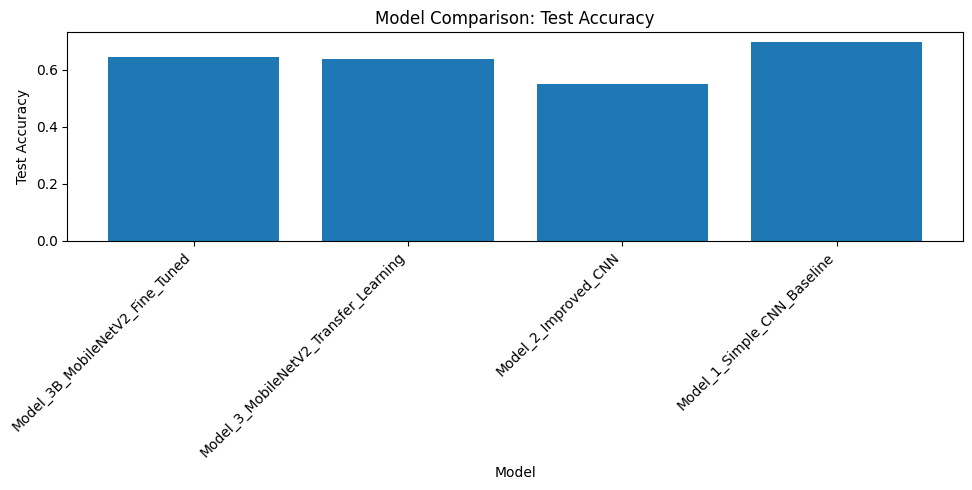

Accuracy comparison graph saved at:
/content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/final_model_comparison_results/comparison_test_accuracy.png


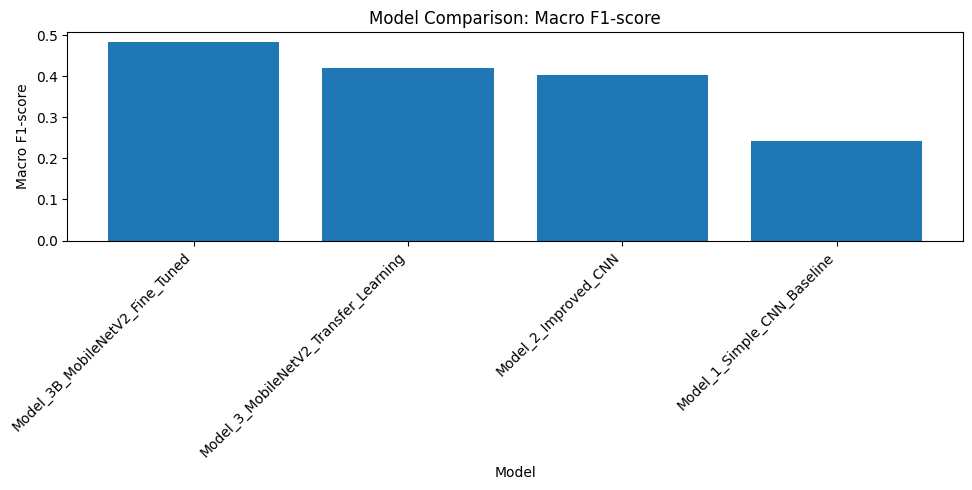

Macro F1 comparison graph saved at:
/content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/final_model_comparison_results/comparison_macro_f1.png


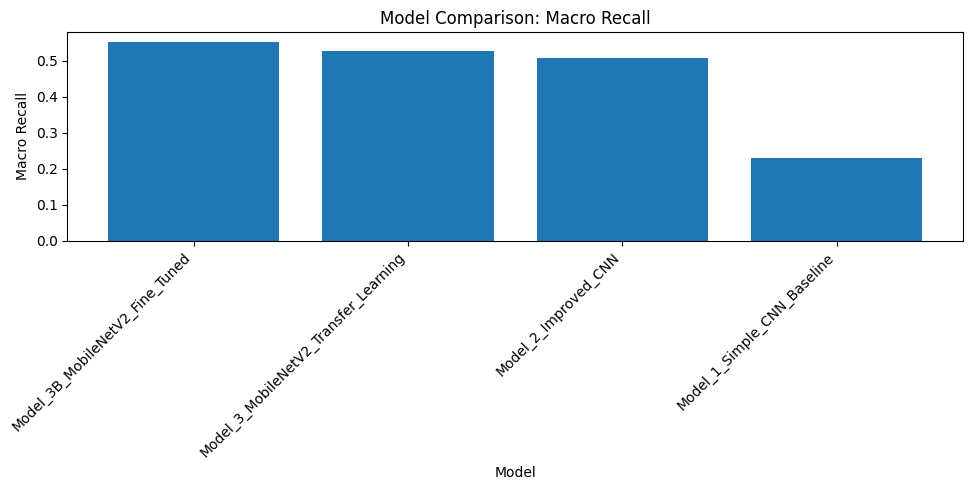

Macro recall comparison graph saved at:
/content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/final_model_comparison_results/comparison_macro_recall.png


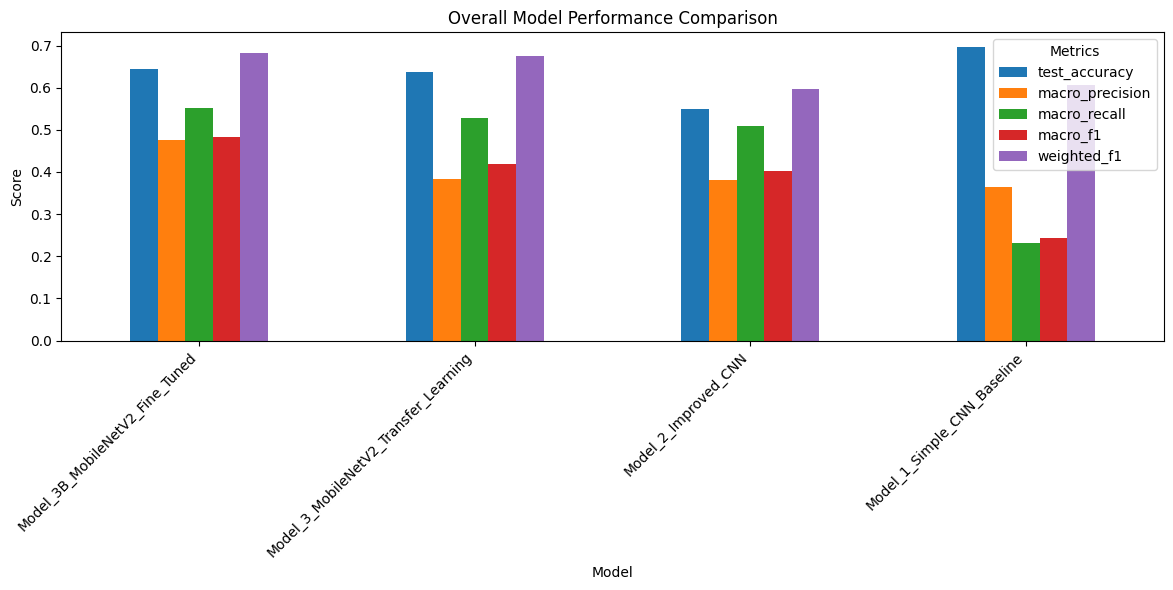

Overall comparison graph saved at:
/content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/final_model_comparison_results/overall_model_comparison.png

Best Model Selected:
{
    "best_model_name": "Model_3B_MobileNetV2_Fine_Tuned",
    "selection_metric": "macro_f1",
    "best_macro_f1": 0.48329414323821035,
    "test_accuracy": 0.6447106003761292,
    "macro_precision": 0.4756792129750772,
    "macro_recall": 0.5517560004627783,
    "weighted_f1": 0.6825288508057836,
    "best_model_path": "/content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3b_mobilenetv2_finetuned_results/model_3b_best.keras",
    "final_model_path": "/content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/model_3b_mobilenetv2_finetuned_results/model_3b_final.keras"
}

Best model info saved at:
/content/drive/MyDrive/DeepLearningProject/HAM10000/extracted/final_model_comparison_results/best_model_info.json

Best model copied to:
/content/drive/MyDrive/DeepLearningProject/HAM10000/extract

In [ ]:
# ============================================================
# COMPARE ALL SAVED MODELS AND SELECT BEST MODEL
# Dataset: HAM10000
# Purpose:
# 1. Load saved metrics from all trained models
# 2. Create comparison table
# 3. Plot comparison graphs
# 4. Select best model using Macro F1-score
# 5. Save final comparison and best model information
# ============================================================

# ------------------------------------------------------------
# 1. Import required libraries
# ------------------------------------------------------------

import os
import json
import shutil
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 2. Define base path
# ------------------------------------------------------------

base_path = "/content/drive/MyDrive/DeepLearningProject/HAM10000/extracted"

comparison_results_path = os.path.join(base_path, "final_model_comparison_results")
os.makedirs(comparison_results_path, exist_ok=True)

print("Final comparison results will be saved at:")
print(comparison_results_path)

# ------------------------------------------------------------
# 3. Define saved metric file paths
# ------------------------------------------------------------

metrics_files = [
    os.path.join(base_path, "model_1_baseline_results", "model_1_metrics.json"),
    os.path.join(base_path, "model_2_improved_cnn_results", "model_2_metrics.json"),
    os.path.join(base_path, "model_3_mobilenetv2_results", "model_3_metrics.json"),
    os.path.join(base_path, "model_3b_mobilenetv2_finetuned_results", "model_3b_metrics.json")
]

# ------------------------------------------------------------
# 4. Load all available model metrics
# ------------------------------------------------------------

comparison_rows = []

for metrics_path in metrics_files:
    if os.path.exists(metrics_path):
        with open(metrics_path, "r") as f:
            metrics = json.load(f)

        comparison_rows.append({
            "model_name": metrics["model_name"],
            "test_accuracy": metrics["test_accuracy"],
            "macro_precision": metrics["precision_macro"],
            "macro_recall": metrics["recall_macro"],
            "macro_f1": metrics["f1_macro"],
            "weighted_f1": metrics["f1_weighted"],
            "best_model_path": metrics.get("best_model_path", ""),
            "final_model_path": metrics.get("final_model_path", "")
        })
    else:
        print("Missing metrics file:", metrics_path)

# Create comparison dataframe
comparison_df = pd.DataFrame(comparison_rows)

# ------------------------------------------------------------
# 5. Sort models by Macro F1-score
# ------------------------------------------------------------
# Macro F1-score is selected as the main metric because HAM10000 is imbalanced.
# Accuracy alone can be misleading when one class has many more images.

comparison_df = comparison_df.sort_values(
    by="macro_f1",
    ascending=False
).reset_index(drop=True)

print("\nFinal Model Comparison Table:")
display(comparison_df)

# Save comparison table
comparison_csv_path = os.path.join(
    comparison_results_path,
    "final_model_comparison_table.csv"
)

comparison_df.to_csv(comparison_csv_path, index=False)

print("\nComparison table saved at:")
print(comparison_csv_path)

# ------------------------------------------------------------
# 6. Plot Accuracy Comparison
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.bar(comparison_df["model_name"], comparison_df["test_accuracy"])
plt.title("Model Comparison: Test Accuracy")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

accuracy_plot_path = os.path.join(
    comparison_results_path,
    "comparison_test_accuracy.png"
)

plt.savefig(accuracy_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Accuracy comparison graph saved at:")
print(accuracy_plot_path)

# ------------------------------------------------------------
# 7. Plot Macro F1 Comparison
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.bar(comparison_df["model_name"], comparison_df["macro_f1"])
plt.title("Model Comparison: Macro F1-score")
plt.xlabel("Model")
plt.ylabel("Macro F1-score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

macro_f1_plot_path = os.path.join(
    comparison_results_path,
    "comparison_macro_f1.png"
)

plt.savefig(macro_f1_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Macro F1 comparison graph saved at:")
print(macro_f1_plot_path)

# ------------------------------------------------------------
# 8. Plot Macro Recall Comparison
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.bar(comparison_df["model_name"], comparison_df["macro_recall"])
plt.title("Model Comparison: Macro Recall")
plt.xlabel("Model")
plt.ylabel("Macro Recall")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

macro_recall_plot_path = os.path.join(
    comparison_results_path,
    "comparison_macro_recall.png"
)

plt.savefig(macro_recall_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Macro recall comparison graph saved at:")
print(macro_recall_plot_path)

# ------------------------------------------------------------
# 9. Plot all important metrics together
# ------------------------------------------------------------

metrics_to_plot = [
    "test_accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_f1"
]

comparison_df_plot = comparison_df.set_index("model_name")[metrics_to_plot]

comparison_df_plot.plot(kind="bar", figsize=(12, 6))
plt.title("Overall Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Metrics")
plt.tight_layout()

overall_plot_path = os.path.join(
    comparison_results_path,
    "overall_model_comparison.png"
)

plt.savefig(overall_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Overall comparison graph saved at:")
print(overall_plot_path)

# ------------------------------------------------------------
# 10. Select best model
# ------------------------------------------------------------

best_model_row = comparison_df.iloc[0]

best_model_info = {
    "best_model_name": best_model_row["model_name"],
    "selection_metric": "macro_f1",
    "best_macro_f1": float(best_model_row["macro_f1"]),
    "test_accuracy": float(best_model_row["test_accuracy"]),
    "macro_precision": float(best_model_row["macro_precision"]),
    "macro_recall": float(best_model_row["macro_recall"]),
    "weighted_f1": float(best_model_row["weighted_f1"]),
    "best_model_path": best_model_row["best_model_path"],
    "final_model_path": best_model_row["final_model_path"]
}

print("\nBest Model Selected:")
print(json.dumps(best_model_info, indent=4))

# Save best model info
best_model_info_path = os.path.join(
    comparison_results_path,
    "best_model_info.json"
)

with open(best_model_info_path, "w") as f:
    json.dump(best_model_info, f, indent=4)

print("\nBest model info saved at:")
print(best_model_info_path)

# ------------------------------------------------------------
# 11. Copy best model to final comparison folder
# ------------------------------------------------------------

best_model_source_path = best_model_row["best_model_path"]

if os.path.exists(best_model_source_path):
    best_model_copy_path = os.path.join(
        comparison_results_path,
        "BEST_MODEL.keras"
    )

    shutil.copy(best_model_source_path, best_model_copy_path)

    print("\nBest model copied to:")
    print(best_model_copy_path)
else:
    print("\nBest model file not found:")
    print(best_model_source_path)

# ------------------------------------------------------------
# 12. Final summary
# ------------------------------------------------------------

print("\nFINAL MODEL SELECTION COMPLETED")
print("Best model:", best_model_info["best_model_name"])
print("Macro F1-score:", best_model_info["best_macro_f1"])
print("Test Accuracy:", best_model_info["test_accuracy"])
print("Macro Recall:", best_model_info["macro_recall"])
print("Weighted F1-score:", best_model_info["weighted_f1"])

In [ ]:
!pip install -q gradio

In [ ]:
# ============================================================
# CLEAN SEQUENCED GRADIO UI FOR HAM10000 PROJECT
# This UI does NOT retrain models.
# It loads saved results, plots, reports, and best model from Google Drive.
# ============================================================

!pip install -q gradio

from google.colab import drive
drive.mount('/content/drive')

import os
import json
import numpy as np
import pandas as pd
import gradio as gr
import tensorflow as tf

from PIL import Image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


# ============================================================
# 1. PROJECT PATHS
# ============================================================

base_path = "/content/drive/MyDrive/DeepLearningProject/HAM10000/extracted"

metadata_path = os.path.join(base_path, "HAM10000_metadata.csv")
image_dir_1 = os.path.join(base_path, "HAM10000_images_part_1")
image_dir_2 = os.path.join(base_path, "HAM10000_images_part_2")
split_path = os.path.join(base_path, "splits")

model1_path = os.path.join(base_path, "model_1_baseline_results")
model2_path = os.path.join(base_path, "model_2_improved_cnn_results")
model3_path = os.path.join(base_path, "model_3_mobilenetv2_results")
model3b_path = os.path.join(base_path, "model_3b_mobilenetv2_finetuned_results")

comparison_results_path = os.path.join(base_path, "final_model_comparison_results")
auc_results_path = os.path.join(base_path, "final_auc_comparison")

best_model_path = os.path.join(model3b_path, "model_3b_best.keras")


# ============================================================
# 2. CLASS LABELS
# ============================================================

class_labels = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

disease_names = {
    "akiec": "Actinic Keratoses / Intraepithelial Carcinoma",
    "bcc": "Basal Cell Carcinoma",
    "bkl": "Benign Keratosis-like Lesions",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic Nevi",
    "vasc": "Vascular Lesions"
}


# ============================================================
# 3. BASIC HELPERS
# ============================================================

def exists_icon(path):
    return "✅ Found" if os.path.exists(path) else "❌ Missing"

def load_json_file(path):
    if os.path.exists(path):
        with open(path, "r") as f:
            return json.load(f)
    return None

def load_csv_file(path):
    if os.path.exists(path):
        return pd.read_csv(path)
    return pd.DataFrame({"Message": [f"File not found: {path}"]})

def safe_img(path):
    return path if os.path.exists(path) else None

def empty_df():
    return pd.DataFrame()

def format_num(value):
    try:
        return f"{float(value):.4f}"
    except:
        return str(value)

def get_metrics_df(metrics_path):
    metrics = load_json_file(metrics_path)

    if metrics is None:
        return pd.DataFrame({"Metric": ["Status"], "Value": ["Metrics file not found"]})

    wanted_keys = [
        "model_name",
        "test_accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "f1_weighted",
        "auc_macro",
        "auc_weighted"
    ]

    rows = []
    for key in wanted_keys:
        value = metrics.get(key, "Not available")
        if isinstance(value, (int, float)):
            value = format_num(value)
        rows.append({"Metric": key, "Value": value})

    return pd.DataFrame(rows)

def get_metric_value(metrics_path, key):
    metrics = load_json_file(metrics_path)
    if metrics is None:
        return "N/A"
    return format_num(metrics.get(key, "N/A"))


# ============================================================
# 4. MODEL CONFIGURATION
# ============================================================

model_info = {
    "3. Model 1: Simple CNN Baseline": {
        "folder": model1_path,
        "metrics": os.path.join(model1_path, "model_1_metrics.json"),
        "report": os.path.join(model1_path, "model_1_classification_report.csv"),
        "acc_plot": os.path.join(model1_path, "model_1_accuracy_curve.png"),
        "loss_plot": os.path.join(model1_path, "model_1_loss_curve.png"),
        "cm_plot": os.path.join(model1_path, "model_1_confusion_matrix.png"),
        "color": "#ef4444",
        "title": "Model 1: Simple CNN Baseline",
        "subtitle": "First baseline model trained from scratch",
        "architecture": """
        <ul>
            <li>Conv2D 32 filters + MaxPooling</li>
            <li>Conv2D 64 filters + MaxPooling</li>
            <li>Conv2D 128 filters + MaxPooling</li>
            <li>Flatten layer</li>
            <li>Dense 128 + Dropout 0.5</li>
            <li>Softmax output for 7 classes</li>
        </ul>
        """,
        "finding": "High accuracy, but weak macro F1 because it predicted mostly the majority class nv."
    },
    "4. Model 2: Improved CNN": {
        "folder": model2_path,
        "metrics": os.path.join(model2_path, "model_2_metrics.json"),
        "report": os.path.join(model2_path, "model_2_classification_report.csv"),
        "acc_plot": os.path.join(model2_path, "model_2_accuracy_curve.png"),
        "loss_plot": os.path.join(model2_path, "model_2_loss_curve.png"),
        "cm_plot": os.path.join(model2_path, "model_2_confusion_matrix.png"),
        "color": "#f97316",
        "title": "Model 2: Improved CNN",
        "subtitle": "Improved CNN using class weights and regularization",
        "architecture": """
        <ul>
            <li>Conv2D blocks with BatchNormalization</li>
            <li>MaxPooling after each block</li>
            <li>GlobalAveragePooling2D instead of Flatten</li>
            <li>Dense 256 + Dropout 0.5</li>
            <li>Dense 128 + Dropout 0.3</li>
            <li>Class weights to handle imbalance</li>
        </ul>
        """,
        "finding": "Lower accuracy than Model 1, but better macro recall and minority-class detection."
    },
    "5. Model 3: MobileNetV2": {
        "folder": model3_path,
        "metrics": os.path.join(model3_path, "model_3_metrics.json"),
        "report": os.path.join(model3_path, "model_3_classification_report.csv"),
        "acc_plot": os.path.join(model3_path, "model_3_accuracy_curve.png"),
        "loss_plot": os.path.join(model3_path, "model_3_loss_curve.png"),
        "cm_plot": os.path.join(model3_path, "model_3_confusion_matrix.png"),
        "color": "#7c3aed",
        "title": "Model 3: MobileNetV2 Transfer Learning",
        "subtitle": "Pretrained MobileNetV2 with frozen base model",
        "architecture": """
        <ul>
            <li>MobileNetV2 pretrained on ImageNet</li>
            <li>Base model frozen</li>
            <li>GlobalAveragePooling2D</li>
            <li>Dense 256 + Dropout 0.5</li>
            <li>Dense 128 + Dropout 0.3</li>
            <li>Softmax output layer</li>
        </ul>
        """,
        "finding": "Better balance between accuracy and macro F1 compared with Model 1 and Model 2."
    },
    "6. Model 3B: Fine-Tuned MobileNetV2": {
        "folder": model3b_path,
        "metrics": os.path.join(model3b_path, "model_3b_metrics.json"),
        "report": os.path.join(model3b_path, "model_3b_classification_report.csv"),
        "acc_plot": os.path.join(model3b_path, "model_3b_accuracy_curve.png"),
        "loss_plot": os.path.join(model3b_path, "model_3b_loss_curve.png"),
        "cm_plot": os.path.join(model3b_path, "model_3b_confusion_matrix.png"),
        "color": "#059669",
        "title": "Model 3B: Fine-Tuned MobileNetV2",
        "subtitle": "Best model after fine-tuning upper MobileNetV2 layers",
        "architecture": """
        <ul>
            <li>Loaded best MobileNetV2 model</li>
            <li>Fine-tuned last 40 layers</li>
            <li>BatchNormalization layers kept frozen</li>
            <li>Very low learning rate: 1e-5</li>
            <li>Class weights used again</li>
            <li>Softmax output layer</li>
        </ul>
        """,
        "finding": "Best overall model based on macro F1-score, macro recall, and weighted F1-score."
    }
}


# ============================================================
# 5. HTML HELPERS
# ============================================================

def page_card(title, subtitle, body, color="#2563eb"):
    return f"""
    <div class="page-card" style="border-top: 7px solid {color};">
        <h1>{title}</h1>
        <h3>{subtitle}</h3>
        <div class="body-text">{body}</div>
    </div>
    """

def metric_cards(metrics_path):
    metrics = load_json_file(metrics_path)

    if metrics is None:
        return """
        <div class="metric-grid">
            <div class="metric-box"><h2>N/A</h2><p>Metrics Not Found</p></div>
        </div>
        """

    values = {
        "Test Accuracy": metrics.get("test_accuracy", "N/A"),
        "Macro F1": metrics.get("f1_macro", "N/A"),
        "Macro Recall": metrics.get("recall_macro", "N/A"),
        "Weighted F1": metrics.get("f1_weighted", "N/A")
    }

    html = '<div class="metric-grid">'
    for name, value in values.items():
        html += f"""
        <div class="metric-box">
            <h2>{format_num(value)}</h2>
            <p>{name}</p>
        </div>
        """
    html += "</div>"

    return html


# ============================================================
# 6. WORKFLOW FUNCTIONS
# ============================================================

def run_step(step):
    """
    One function controls all workflow steps.
    It clears previous output and displays only selected step.
    """

    # Step 1
    if step == "1. Project Status":
        body = f"""
        <div class="status-grid">
            <div class="status-box"><h2>{exists_icon(metadata_path)}</h2><p>Metadata CSV</p></div>
            <div class="status-box"><h2>{exists_icon(image_dir_1)}</h2><p>Image Folder 1</p></div>
            <div class="status-box"><h2>{exists_icon(image_dir_2)}</h2><p>Image Folder 2</p></div>
            <div class="status-box"><h2>{exists_icon(split_path)}</h2><p>Splits Folder</p></div>
            <div class="status-box"><h2>{exists_icon(model1_path)}</h2><p>Model 1 Results</p></div>
            <div class="status-box"><h2>{exists_icon(model2_path)}</h2><p>Model 2 Results</p></div>
            <div class="status-box"><h2>{exists_icon(model3_path)}</h2><p>Model 3 Results</p></div>
            <div class="status-box"><h2>{exists_icon(model3b_path)}</h2><p>Model 3B Results</p></div>
        </div>
        <div class="note-box">
            Best saved model path:<br>
            <code>{best_model_path}</code><br><br>
            Status: <b>{exists_icon(best_model_path)}</b>
        </div>
        """

        html = page_card(
            "Step 1: Project Status",
            "Checking dataset, saved model folders, and best model file",
            body,
            "#2563eb"
        )

        return html, pd.DataFrame(), pd.DataFrame(), None, None, None

    # Step 2
    if step == "2. Preprocessing":
        train_csv = os.path.join(split_path, "train.csv")
        val_csv = os.path.join(split_path, "val.csv")
        test_csv = os.path.join(split_path, "test.csv")

        train_df = load_csv_file(train_csv)
        val_df = load_csv_file(val_csv)
        test_df = load_csv_file(test_csv)

        meta_count = len(pd.read_csv(metadata_path)) if os.path.exists(metadata_path) else "N/A"
        count_1 = len([f for f in os.listdir(image_dir_1) if f.endswith(".jpg")]) if os.path.exists(image_dir_1) else 0
        count_2 = len([f for f in os.listdir(image_dir_2) if f.endswith(".jpg")]) if os.path.exists(image_dir_2) else 0

        body = f"""
        <div class="pipeline">
            <div>Load Metadata</div>
            <span>→</span>
            <div>Connect Image Paths</div>
            <span>→</span>
            <div>Split 70/20/10</div>
            <span>→</span>
            <div>Resize 224×224</div>
            <span>→</span>
            <div>Normalize + Augment</div>
        </div>

        <div class="metric-grid">
            <div class="metric-box"><h2>{meta_count}</h2><p>Metadata Records</p></div>
            <div class="metric-box"><h2>{count_1 + count_2}</h2><p>Total Images</p></div>
            <div class="metric-box"><h2>{len(train_df)}</h2><p>Train Images</p></div>
            <div class="metric-box"><h2>{len(test_df)}</h2><p>Test Images</p></div>
        </div>

        <div class="note-box">
            Images were kept in RGB format because color patterns are important in skin lesion classification.
            Training images used augmentation, while validation and test images were only normalized.
        </div>
        """

        if "dx" in train_df.columns:
            split_table = pd.DataFrame({
                "Train": train_df["dx"].value_counts(),
                "Validation": val_df["dx"].value_counts(),
                "Test": test_df["dx"].value_counts()
            }).fillna(0).astype(int).reset_index().rename(columns={"index": "Class"})
        else:
            split_table = pd.DataFrame()

        html = page_card(
            "Step 2: Preprocessing",
            "Dataset preparation before CNN training",
            body,
            "#0f766e"
        )

        return html, split_table, pd.DataFrame(), None, None, None

    # Model steps
    if step in model_info:
        info = model_info[step]

        metrics_df = get_metrics_df(info["metrics"])
        report_df = load_csv_file(info["report"])

        body = f"""
        <div class="two-column">
            <div>
                <h3>Architecture</h3>
                {info["architecture"]}
            </div>
            <div>
                <h3>Key Finding</h3>
                <p>{info["finding"]}</p>
            </div>
        </div>
        {metric_cards(info["metrics"])}
        """

        html = page_card(
            info["title"],
            info["subtitle"],
            body,
            info["color"]
        )

        return (
            html,
            metrics_df,
            report_df,
            safe_img(info["acc_plot"]),
            safe_img(info["loss_plot"]),
            safe_img(info["cm_plot"])
        )

    # Final comparison
    if step == "7. Final Comparison":
        comparison_files = [
            os.path.join(auc_results_path, "final_model_comparison_with_auc.csv"),
            os.path.join(comparison_results_path, "final_model_comparison_table.csv"),
            os.path.join(model3b_path, "model_1_2_3_3b_comparison.csv")
        ]

        comparison_df = None

        for path in comparison_files:
            if os.path.exists(path):
                comparison_df = pd.read_csv(path)
                break

        if comparison_df is None:
            rows = []
            for step_name, info in model_info.items():
                m = load_json_file(info["metrics"])
                if m:
                    rows.append({
                        "model_name": m.get("model_name"),
                        "test_accuracy": m.get("test_accuracy"),
                        "macro_precision": m.get("precision_macro"),
                        "macro_recall": m.get("recall_macro"),
                        "macro_f1": m.get("f1_macro"),
                        "weighted_f1": m.get("f1_weighted"),
                        "auc_macro": m.get("auc_macro", "Not calculated")
                    })
            comparison_df = pd.DataFrame(rows)

        if "macro_f1" in comparison_df.columns:
            comparison_df = comparison_df.sort_values(by="macro_f1", ascending=False).reset_index(drop=True)

        best = comparison_df.iloc[0].to_dict()
        best_name = best.get("model_name", best.get("model", "Unknown"))

        body = f"""
        <div class="best-model-card">
            <h2>Best Model Selected</h2>
            <h1>{best_name}</h1>
            <p>Selected using Macro F1-score because HAM10000 is imbalanced.</p>
        </div>

        <div class="metric-grid">
            <div class="metric-box"><h2>{format_num(best.get("test_accuracy", "N/A"))}</h2><p>Test Accuracy</p></div>
            <div class="metric-box"><h2>{format_num(best.get("macro_f1", "N/A"))}</h2><p>Macro F1</p></div>
            <div class="metric-box"><h2>{format_num(best.get("macro_recall", "N/A"))}</h2><p>Macro Recall</p></div>
            <div class="metric-box"><h2>{format_num(best.get("weighted_f1", "N/A"))}</h2><p>Weighted F1</p></div>
        </div>

        <div class="note-box">
            Model 1 had higher accuracy, but it was biased toward the majority class.
            Fine-tuned MobileNetV2 was selected because it gave the best balance across classes.
        </div>
        """

        html = page_card(
            "Step 7: Final Model Comparison",
            "Comparing all saved models and selecting the best model",
            body,
            "#111827"
        )

        return html, comparison_df, pd.DataFrame(), None, None, None

    return "", pd.DataFrame(), pd.DataFrame(), None, None, None


# ============================================================
# 7. PREDICTION FUNCTION
# ============================================================

loaded_best_model = None

def predict_image(input_image):
    global loaded_best_model

    if input_image is None:
        return "Please upload an image first.", {}

    if not os.path.exists(best_model_path):
        return f"Best model not found at:\n{best_model_path}", {}

    if loaded_best_model is None:
        loaded_best_model = load_model(best_model_path)

    image = input_image.convert("RGB")
    image = image.resize((224, 224))

    image_array = np.array(image)
    image_array = np.expand_dims(image_array, axis=0)
    image_array = preprocess_input(image_array)

    preds = loaded_best_model.predict(image_array, verbose=0)[0]
    pred_index = int(np.argmax(preds))

    pred_label = class_labels[pred_index]
    pred_name = disease_names[pred_label]
    confidence = float(preds[pred_index] * 100)

    probs = {
        f"{class_labels[i]} - {disease_names[class_labels[i]]}": float(preds[i])
        for i in range(len(class_labels))
    }

    result = f"""
Predicted Class: {pred_label}

Disease Name: {pred_name}

Confidence: {confidence:.2f}%

Model Used: Fine-Tuned MobileNetV2

Note: This result is for educational project demonstration only.
It should not be used as a medical diagnosis.
"""

    return result, probs


# ============================================================
# 8. CUSTOM CSS
# ============================================================

custom_css = """
.gradio-container {
    max-width: 1450px !important;
    font-family: 'Inter', 'Segoe UI', sans-serif;
}

body {
    background: #f1f5f9;
}

#hero {
    background: linear-gradient(135deg, #0f172a, #1d4ed8, #7c3aed);
    padding: 38px;
    border-radius: 28px;
    color: white;
    margin-bottom: 20px;
    box-shadow: 0 20px 45px rgba(15, 23, 42, 0.25);
}

#hero h1 {
    color: white !important;
    font-size: 42px;
    margin: 0 0 10px 0;
}

#hero p {
    color: #e0e7ff !important;
    font-size: 18px;
    margin: 0;
    opacity: 0.95;
}

.page-card {
    background: white;
    padding: 28px;
    border-radius: 24px;
    box-shadow: 0 12px 30px rgba(15, 23, 42, 0.10);
    margin-bottom: 16px;
}

.page-card h1 {
    margin: 0;
    font-size: 30px;
    color: #111827;
}

.page-card h3 {
    margin-top: 8px;
    color: #64748b;
}

.body-text {
    margin-top: 18px;
    color: #334155;
    font-size: 16px;
}

.metric-grid {
    display: grid;
    grid-template-columns: repeat(4, 1fr);
    gap: 14px;
    margin-top: 20px;
}

.metric-box {
    background: linear-gradient(135deg, #eef2ff, #ffffff);
    border: 1px solid #c7d2fe;
    border-radius: 18px;
    padding: 16px;
    text-align: center;
}

.metric-box h2 {
    margin: 0;
    color: #1d4ed8;
    font-size: 26px;
}

.metric-box p {
    margin: 6px 0 0 0;
    color: #475569;
    font-weight: 700;
}

.status-grid {
    display: grid;
    grid-template-columns: repeat(4, 1fr);
    gap: 14px;
}

.status-box {
    background: #f8fafc;
    padding: 16px;
    border-radius: 16px;
    text-align: center;
    border: 1px solid #e2e8f0;
}

.status-box h2 {
    margin: 0;
    font-size: 22px;
}

.status-box p {
    margin: 6px 0 0 0;
    color: #475569;
    font-weight: 700;
}

.note-box {
    background: #fffbeb;
    border-left: 6px solid #f59e0b;
    padding: 15px;
    border-radius: 14px;
    margin-top: 18px;
    color: #78350f;
}

.pipeline {
    display: flex;
    flex-wrap: wrap;
    align-items: center;
    gap: 10px;
    margin-bottom: 18px;
}

.pipeline div {
    background: #dbeafe;
    color: #1e40af;
    padding: 10px 14px;
    border-radius: 999px;
    font-weight: 800;
}

.pipeline span {
    font-weight: 900;
    color: #64748b;
}

.two-column {
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 20px;
}

.best-model-card {
    background: linear-gradient(135deg, #064e3b, #059669);
    color: white;
    padding: 24px;
    border-radius: 22px;
    box-shadow: 0 12px 28px rgba(6, 78, 59, 0.25);
}

.best-model-card h1,
.best-model-card h2,
.best-model-card p {
    color: white !important;
}

.sidebar-box {
    background: white;
    padding: 18px;
    border-radius: 22px;
    box-shadow: 0 10px 26px rgba(15, 23, 42, 0.10);
    border: 1px solid #e2e8f0;
}

button {
    border-radius: 14px !important;
    font-weight: 800 !important;
}

img {
    border-radius: 16px !important;
}
"""


# ============================================================
# 9. BUILD GRADIO UI
# ============================================================

theme = gr.themes.Soft(
    primary_hue="blue",
    secondary_hue="purple"
)

with gr.Blocks(
    title="HAM10000 Project Dashboard",
    css=custom_css,
    theme=theme
) as demo:

    gr.HTML("""
    <div id="hero">
        <h1>HAM10000 Skin Lesion Classification</h1>
        <p>Sequential Deep Learning Dashboard: Preprocessing → Models → Comparison → Prediction</p>
    </div>
    """)

    with gr.Row():

        # Left workflow panel
        with gr.Column(scale=1, min_width=320):
            gr.HTML("""
            <div class="sidebar-box">
                <h2>Project Workflow</h2>
                <p>Select each step in order and click the button. Only the selected step result will appear.</p>
            </div>
            """)

            step_selector = gr.Radio(
                choices=[
                    "1. Project Status",
                    "2. Preprocessing",
                    "3. Model 1: Simple CNN Baseline",
                    "4. Model 2: Improved CNN",
                    "5. Model 3: MobileNetV2",
                    "6. Model 3B: Fine-Tuned MobileNetV2",
                    "7. Final Comparison"
                ],
                value="1. Project Status",
                label="Select Step"
            )

            run_button = gr.Button("Run Selected Step", variant="primary")

            gr.HTML("""
            <div class="sidebar-box" style="margin-top:16px;">
                <h3>Final Best Model</h3>
                <p><b>Fine-Tuned MobileNetV2</b></p>
                <p>Selected using Macro F1-score because the dataset is imbalanced.</p>
            </div>
            """)

        # Main output panel
        with gr.Column(scale=3):
            step_output = gr.HTML()

            with gr.Row():
                main_table = gr.Dataframe(label="Metrics / Main Table", interactive=False)
                extra_table = gr.Dataframe(label="Classification Report / Extra Table", interactive=False)

            with gr.Row():
                image_1 = gr.Image(label="Accuracy Curve", height=330)
                image_2 = gr.Image(label="Loss Curve", height=330)

            image_3 = gr.Image(label="Confusion Matrix", height=500)

    gr.HTML("""
    <div id="hero" style="margin-top:24px;">
        <h1>Prediction Demo</h1>
        <p>Upload one skin lesion image and predict using the saved best model.</p>
    </div>
    """)

    with gr.Row():
        with gr.Column(scale=1):
            upload_image = gr.Image(type="pil", label="Upload Skin Lesion Image", height=360)
            predict_button = gr.Button("Predict with Best Model", variant="primary")

        with gr.Column(scale=1):
            prediction_text = gr.Textbox(label="Prediction Result", lines=8)
            prediction_label = gr.Label(num_top_classes=7, label="Class Probabilities")

    run_button.click(
        fn=run_step,
        inputs=step_selector,
        outputs=[step_output, main_table, extra_table, image_1, image_2, image_3]
    )

    predict_button.click(
        fn=predict_image,
        inputs=upload_image,
        outputs=[prediction_text, prediction_label]
    )

demo.launch(share=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_1774/568830265.py:712: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_1774/568830265.py:712: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://414dfb542d3e64555c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
